<a href="https://colab.research.google.com/github/parksuejin1026/2025-1-2-OSS/blob/main/Week10/BDA_Week10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [81]:
!pip install koreanize-matplotlib
import koreanize_matplotlib # 한글 폰트 깨짐 방지를 위한 패키지 설치 및 임포트
%config InlineBackend.figure_format = 'retina' # 그래프를 더 선명하게 출력하도록 설정

In [2]:
!pip install pydataset

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.9/15.9 MB 35.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pydataset: filename=pydataset-0.2.0-py3-none-any.whl size=15939415 sha256=154528c62babbcbf043660df7c9478bffb7f3ec77af4f01a6cf7727bdb1d3e0d
  Stored in directory: /root/.cache/pip/wheels/4c/82/ad/f04abc617222b10438b1285ab9b5cfaecd180c10a7c81cff54
Successfully built pydataset


In [82]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np # 데이터 분석 및 시각화에 필요한 기본 라이브러리들을 임포트합니다.

In [64]:
from pydataset import data
iris = data('iris') # pydataset에서 iris 데이터를 로드합니다.
iris.info() # 데이터프레임의 구조, 컬럼명, 데이터 타입 등을 확인합니다.

<class 'pandas.core.frame.DataFrame'>
Index: 150 entries, 1 to 150
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Sepal.Length  150 non-null    float64
 1   Sepal.Width   150 non-null    float64
 2   Petal.Length  150 non-null    float64
 3   Petal.Width   150 non-null    float64
 4   Species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 7.0+ KB


In [65]:
iris.describe() # 수치형 데이터의 기술 통계량(평균, 표준편차, 사분위수 등)을 확인합니다.

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


In [66]:
iris.describe(include = 'all') # 수치형뿐만 아니라 범주형 데이터를 포함한 모든 컬럼의 통계량을 확인합니다.

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
count,150.00,150.00,150.00,150.00,150
unique,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,setosa
freq,NaN,NaN,NaN,NaN,50
mean,5.84,3.06,3.76,1.20,NaN
std,0.83,0.44,1.77,0.76,NaN
min,4.30,2.00,1.00,0.10,NaN
25%,5.10,2.80,1.60,0.30,NaN
50%,5.80,3.00,4.35,1.30,NaN
75%,6.40,3.30,5.10,1.80,NaN


In [67]:
iris.Species.unique() # Species 컬럼에 있는 고유한 종 이름들을 확인합니다.

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [68]:
iris.Species.value_counts() # 각 종별 데이터의 개수를 확인합니다.

,count
Species,
setosa,50
versicolor,50
virginica,50


In [77]:
from IPython.display import display_html
def display_side_by_side(*args):
  """여러 데이터프레임 비교가 쉽게 옆쪽으로 표시한다"""
  html_str = ''
  for df in args:
    html_str += df.to_html() + ' ' * 4
  display_html(html_str.replace('table', 'table style = "display:inline"'), raw = True)

In [83]:
from IPython.display import display_html

def display_series_side_by_side(*args, names=None):
    """여러 판다스 Series를 옆으로 나란히 표시하는 사용자 정의 함수입니다."""
    html_str = ''
    for i, s in enumerate(args):
        if names and i < len(names):
            title = names[i]
        elif s.name is not None:
            title = s.name
        else:
            title = f'Series {i}'

        table_html = s.to_frame(name=title).to_html()
        html_str += table_html + ' ' * 4

    display_html(
        html_str.replace('table', 'table style="display:inline; vertical-align:top"'),
        raw=True
    )

In [78]:
display_side_by_side(iris.head(), iris.tail()) # 데이터의 앞부분과 뒷부분 5행씩을 나란히 출력하여 확인합니다.

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
1,5.1,3.5,1.4,0.2,setosa
2,4.9,3.0,1.4,0.2,setosa
3,4.7,3.2,1.3,0.2,setosa
4,4.6,3.1,1.5,0.2,setosa
5,5.0,3.6,1.4,0.2,setosa
,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
146,6.7,3.0,5.2,2.3,virginica
147,6.3,2.5,5.0,1.9,virginica
148,6.5,3.0,5.2,2.0,virginica
149,6.2,3.4,5.4,2.3,virginica


In [19]:
display_series_side_by_side(iris['Petal.Length'][:5], iris.Species.value_counts())

,Petal.Length
1,1.4
2,1.4
3,1.3
4,1.5
5,1.4
,count
Species,
setosa,50
versicolor,50
virginica,50


In [20]:
display_side_by_side(iris['Petal.Length'][:5].to_frame(), iris.Species.value_counts().to_frame())

,Petal.Length
1,1.4
2,1.4
3,1.3
4,1.5
5,1.4
,count
Species,
setosa,50
versicolor,50
virginica,50


In [21]:
plt.rcParams['figure.figsize'] = (5, 3)

[ 4.  5.  7. 16.  9.  5. 13. 14. 10.  6. 10. 16.  7. 11.  4.  2.  4.  1.
  5.  1.]
[4.3  4.48 4.66 4.84 5.02 5.2  5.38 5.56 5.74 5.92 6.1  6.28 6.46 6.64
 6.82 7.   7.18 7.36 7.54 7.72 7.9 ]
<BarContainer object of 20 artists>


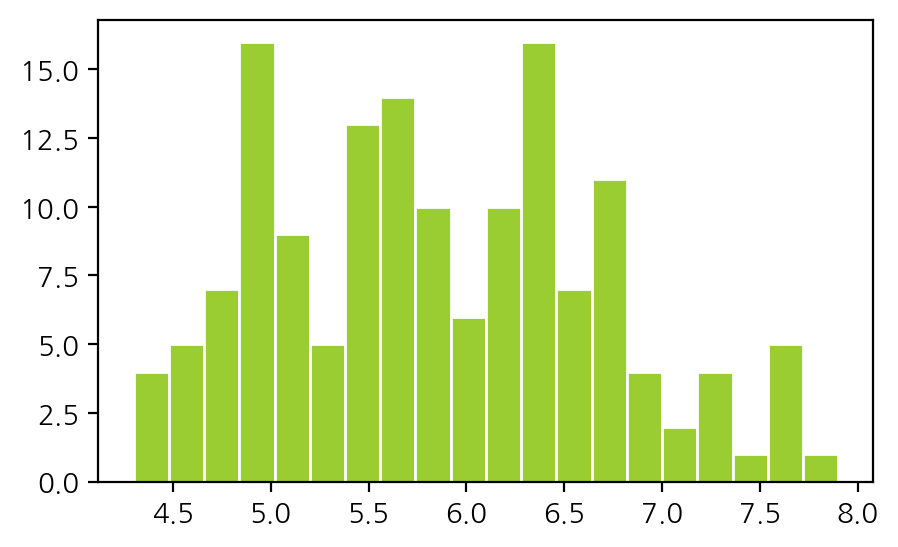

In [60]:
import matplotlib.pyplot as plt

# Sepal.Length 컬럼으로 히스토그램 그리기 (20개 구간)
n, bins, patches = plt.hist(iris['sepal_length'], bins = 20,
                            color='yellowgreen', edgecolor='white')
print(n) # 각 빈에 속한 데이터 개수
print(bins) # 빈의 경계 값들
print(patches) # 히스토그램을 구성하는 막대 객체들

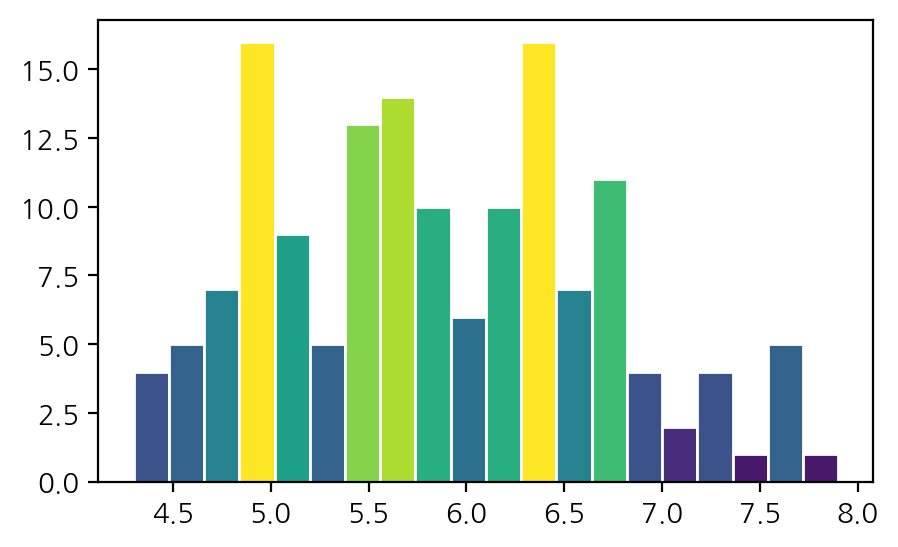

In [61]:
# 히스토그램 막대마다 데이터 빈도에 따라 색상 입히기
n, bins, patches = plt.hist(iris['sepal_length'], bins = 20,
                            color='yellowgreen', edgecolor='white')
for i in range(len(patches)):
    # viridis 컬러맵을 사용하여 빈도가 높을수록 다른 색상이 나타나도록 설정
    patches[i].set_facecolor(plt.cm.viridis(n[i]/max(n)))
plt.show()

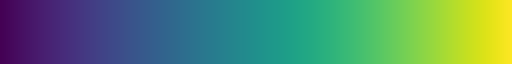

In [24]:
plt.cm.viridis

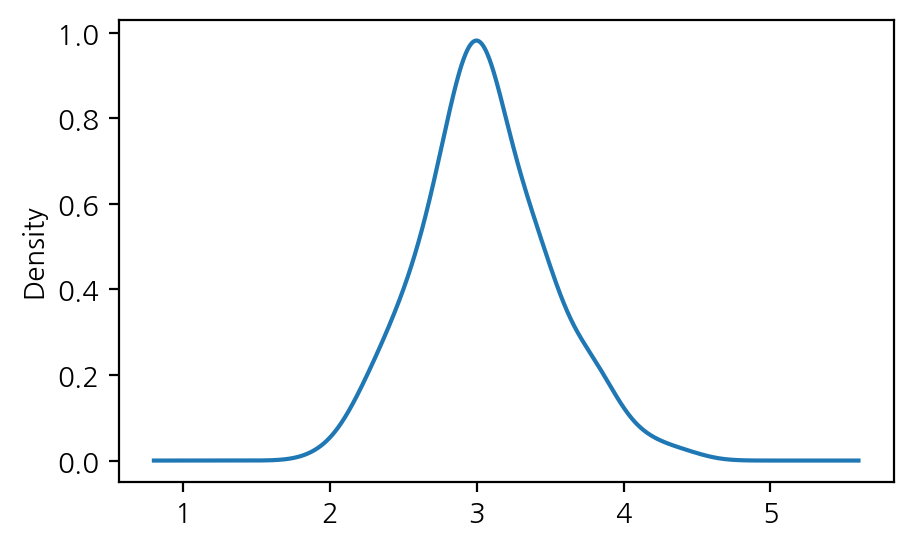

In [69]:
iris['Sepal.Width'].plot.density(); # Sepal.Width의 밀도 추정 그래프(KDE)를 그립니다.

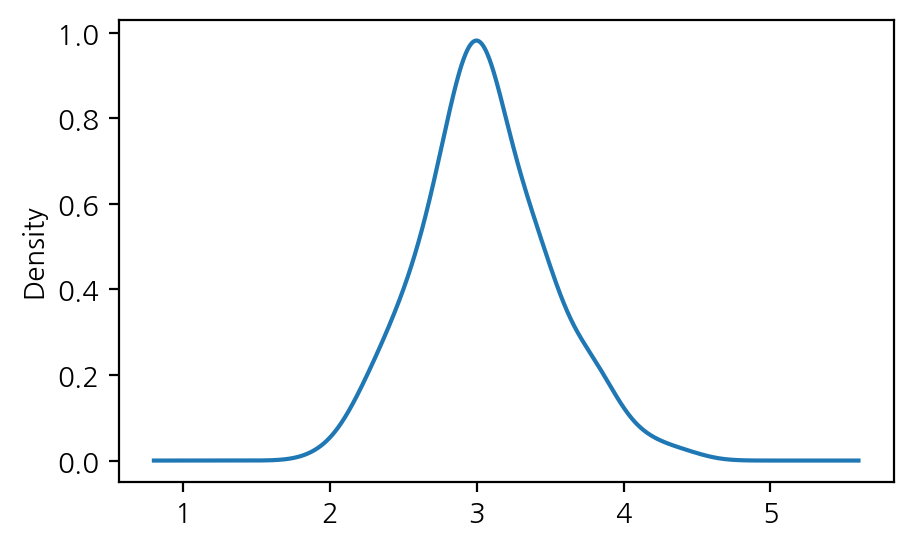

In [84]:
iris['Sepal.Width'].plot.kde(); # plot.density()와 동일하게 커널 밀도 추정 그래프를 그립니다.

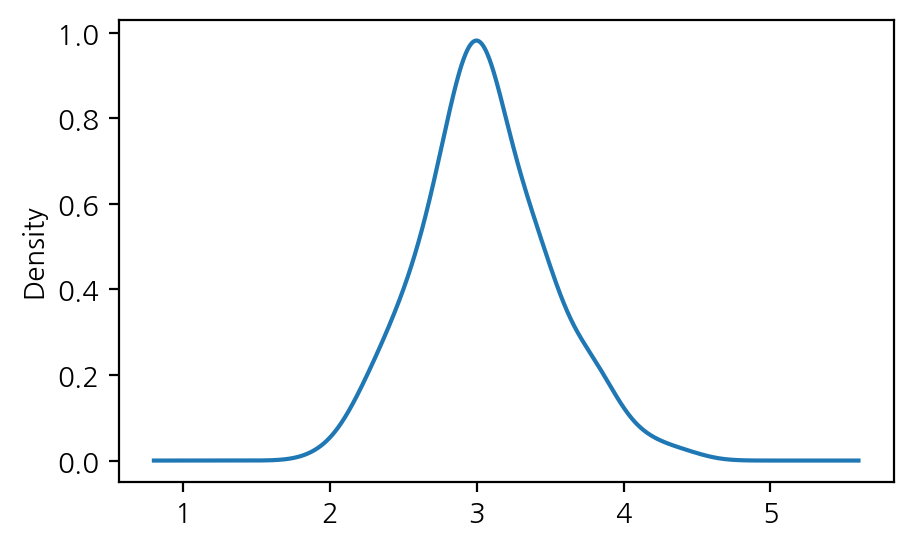

In [27]:
iris['Sepal.Width'].plot.density();

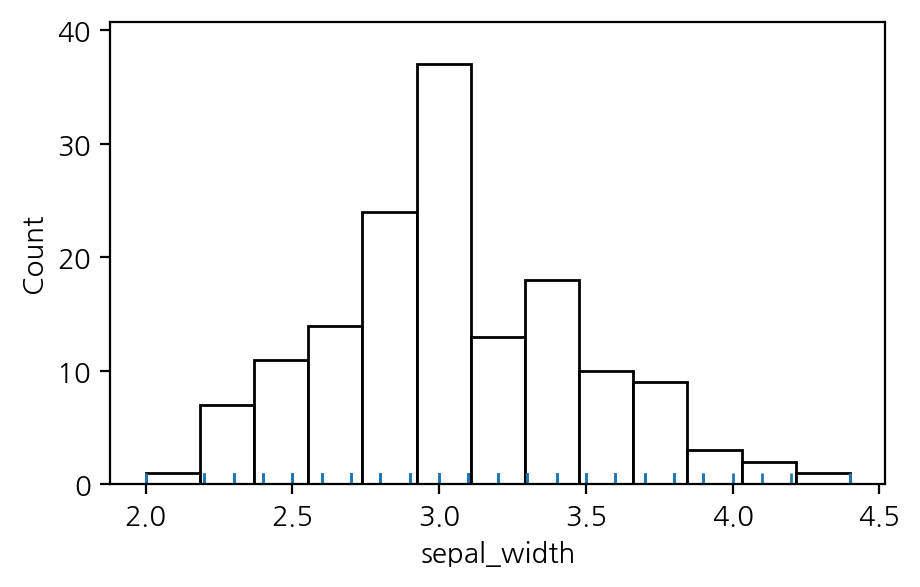

In [62]:
import seaborn as sns
# 히스토그램과 러그플롯(데이터 위치 표시)을 함께 시각화
sns.histplot(data = iris, x = 'sepal_width', color='white')
sns.rugplot(data = iris, x = 'sepal_width');

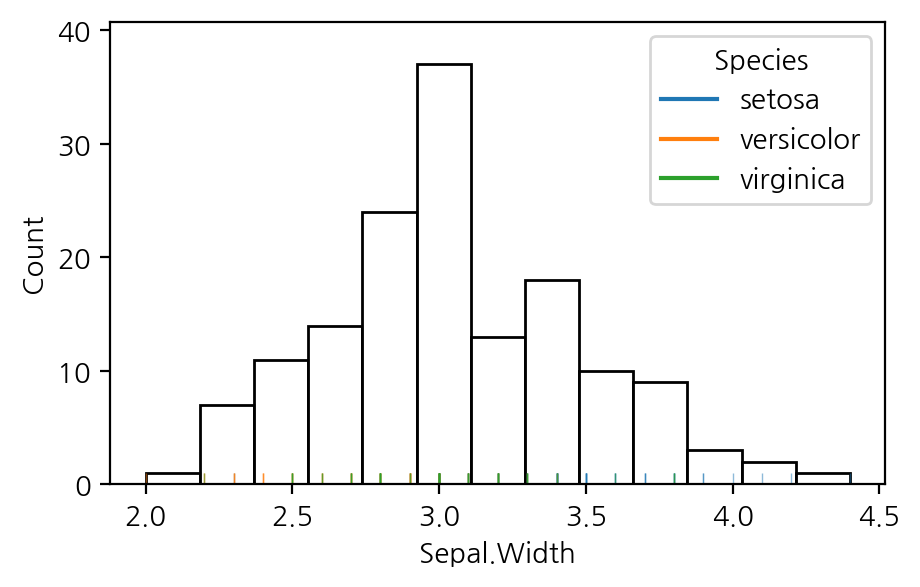

In [70]:
import seaborn as sns
# 히스토그램과 함께 종(Species)별로 색상을 구분한 러그플롯을 그립니다.
sns.histplot(data = iris, x = iris['Sepal.Width'], color='white')
sns.rugplot(data = iris, x = iris['Sepal.Width'], linewidth=0.5, hue='Species', alpha=.5);

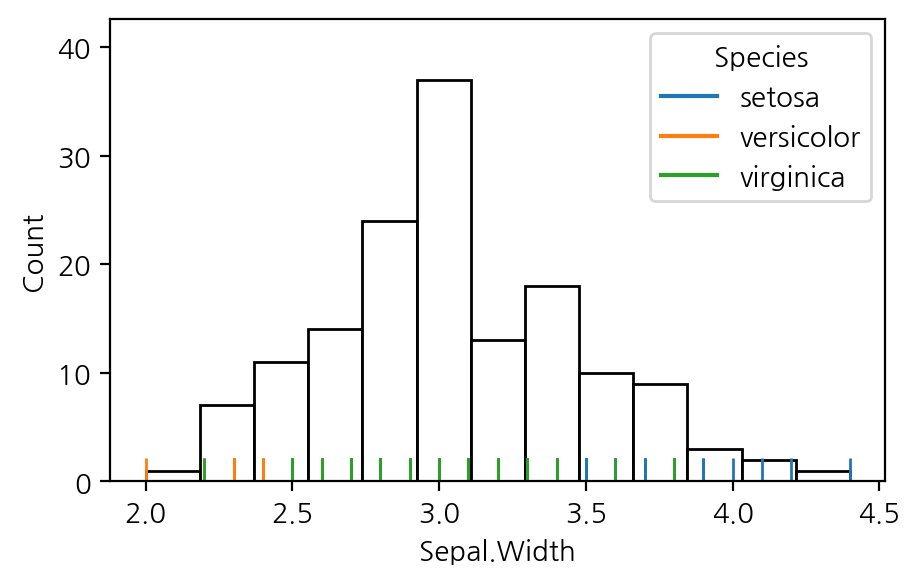

In [31]:
import seaborn as sns
sns.histplot(data = iris, x = iris['Sepal.Width'], color='white')
sns.rugplot(data = iris, x = iris['Sepal.Width'], height=0.05, hue='Species');

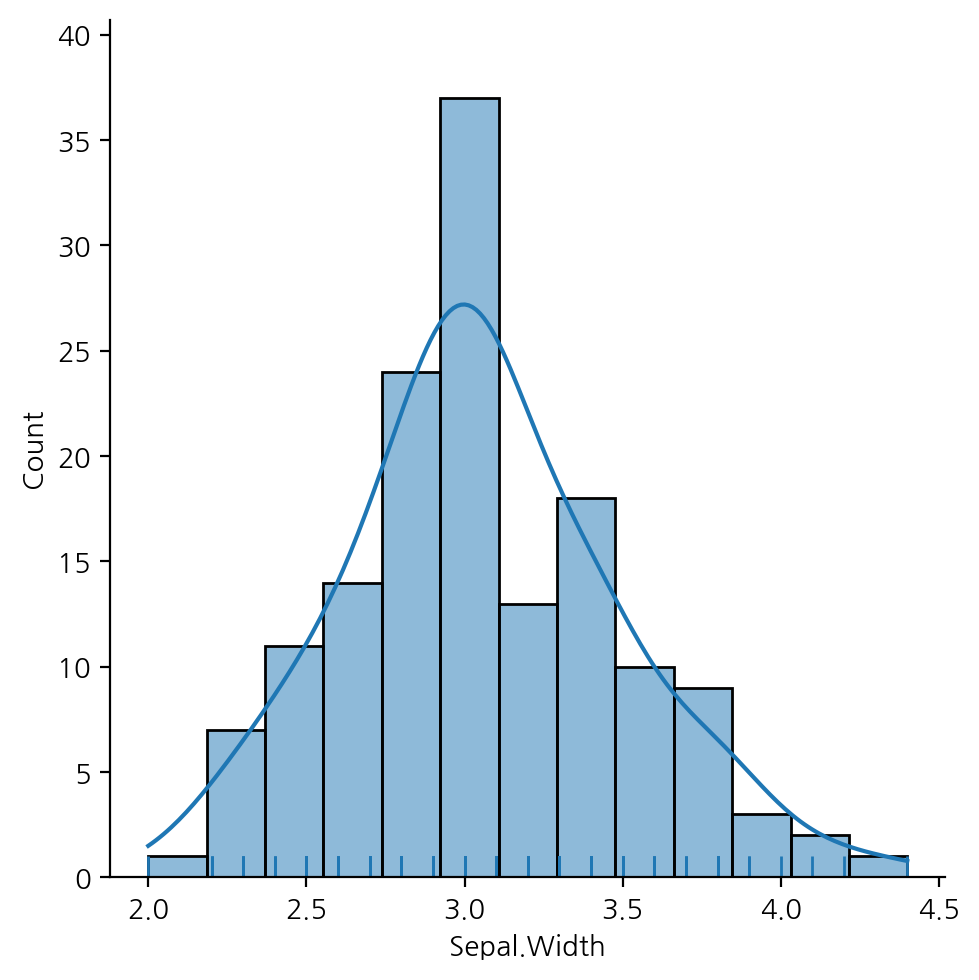

In [71]:
import seaborn as sns
# displot을 사용하여 히스토그램, KDE 곡선, 러그플롯을 한 번에 시각화합니다.
sns.displot(data = iris, x = iris['Sepal.Width'], kde=True, rug=True);

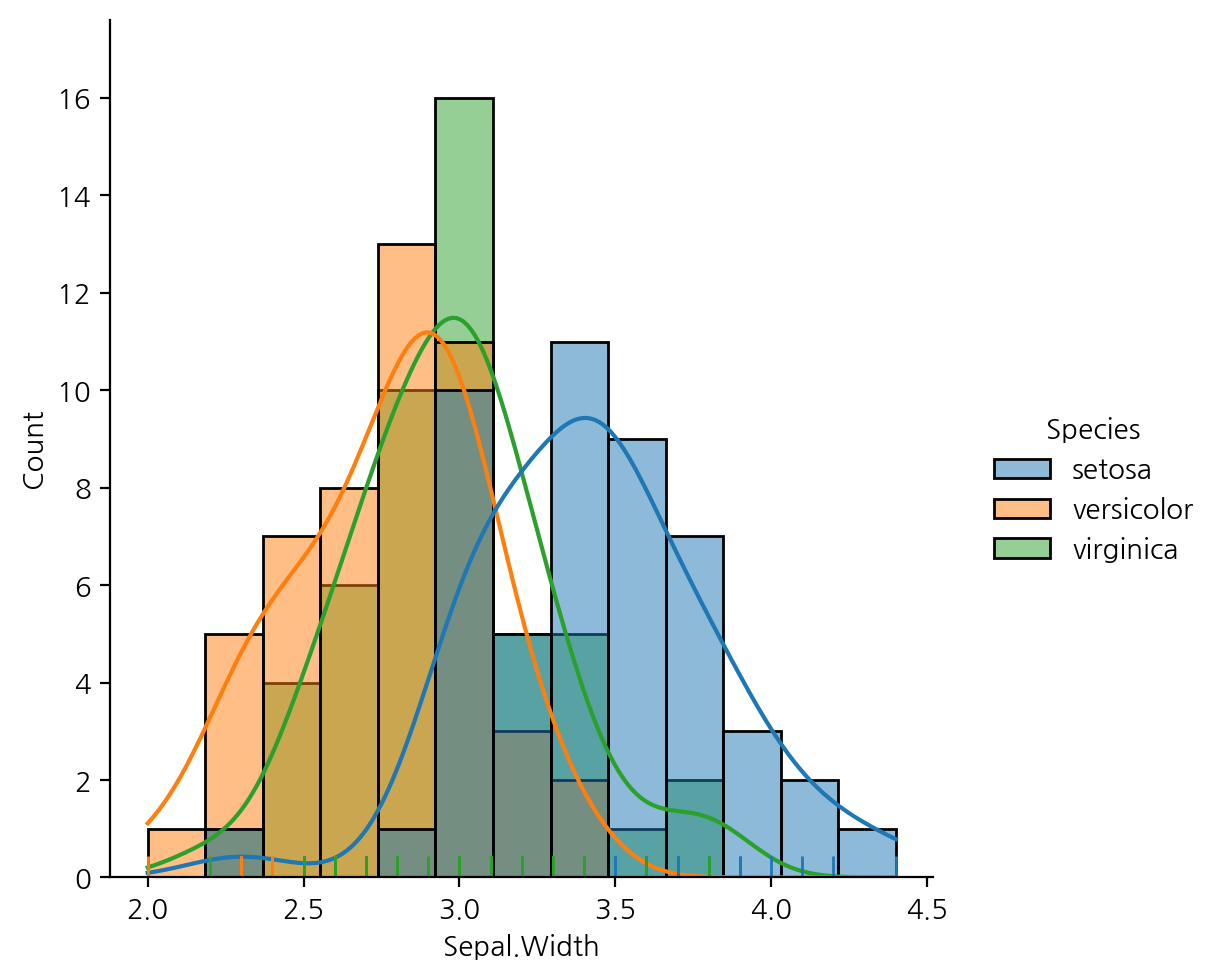

In [33]:
import seaborn as sns
sns.displot(data = iris, x = iris['Sepal.Width'], kde=True, rug=True, hue='Species');

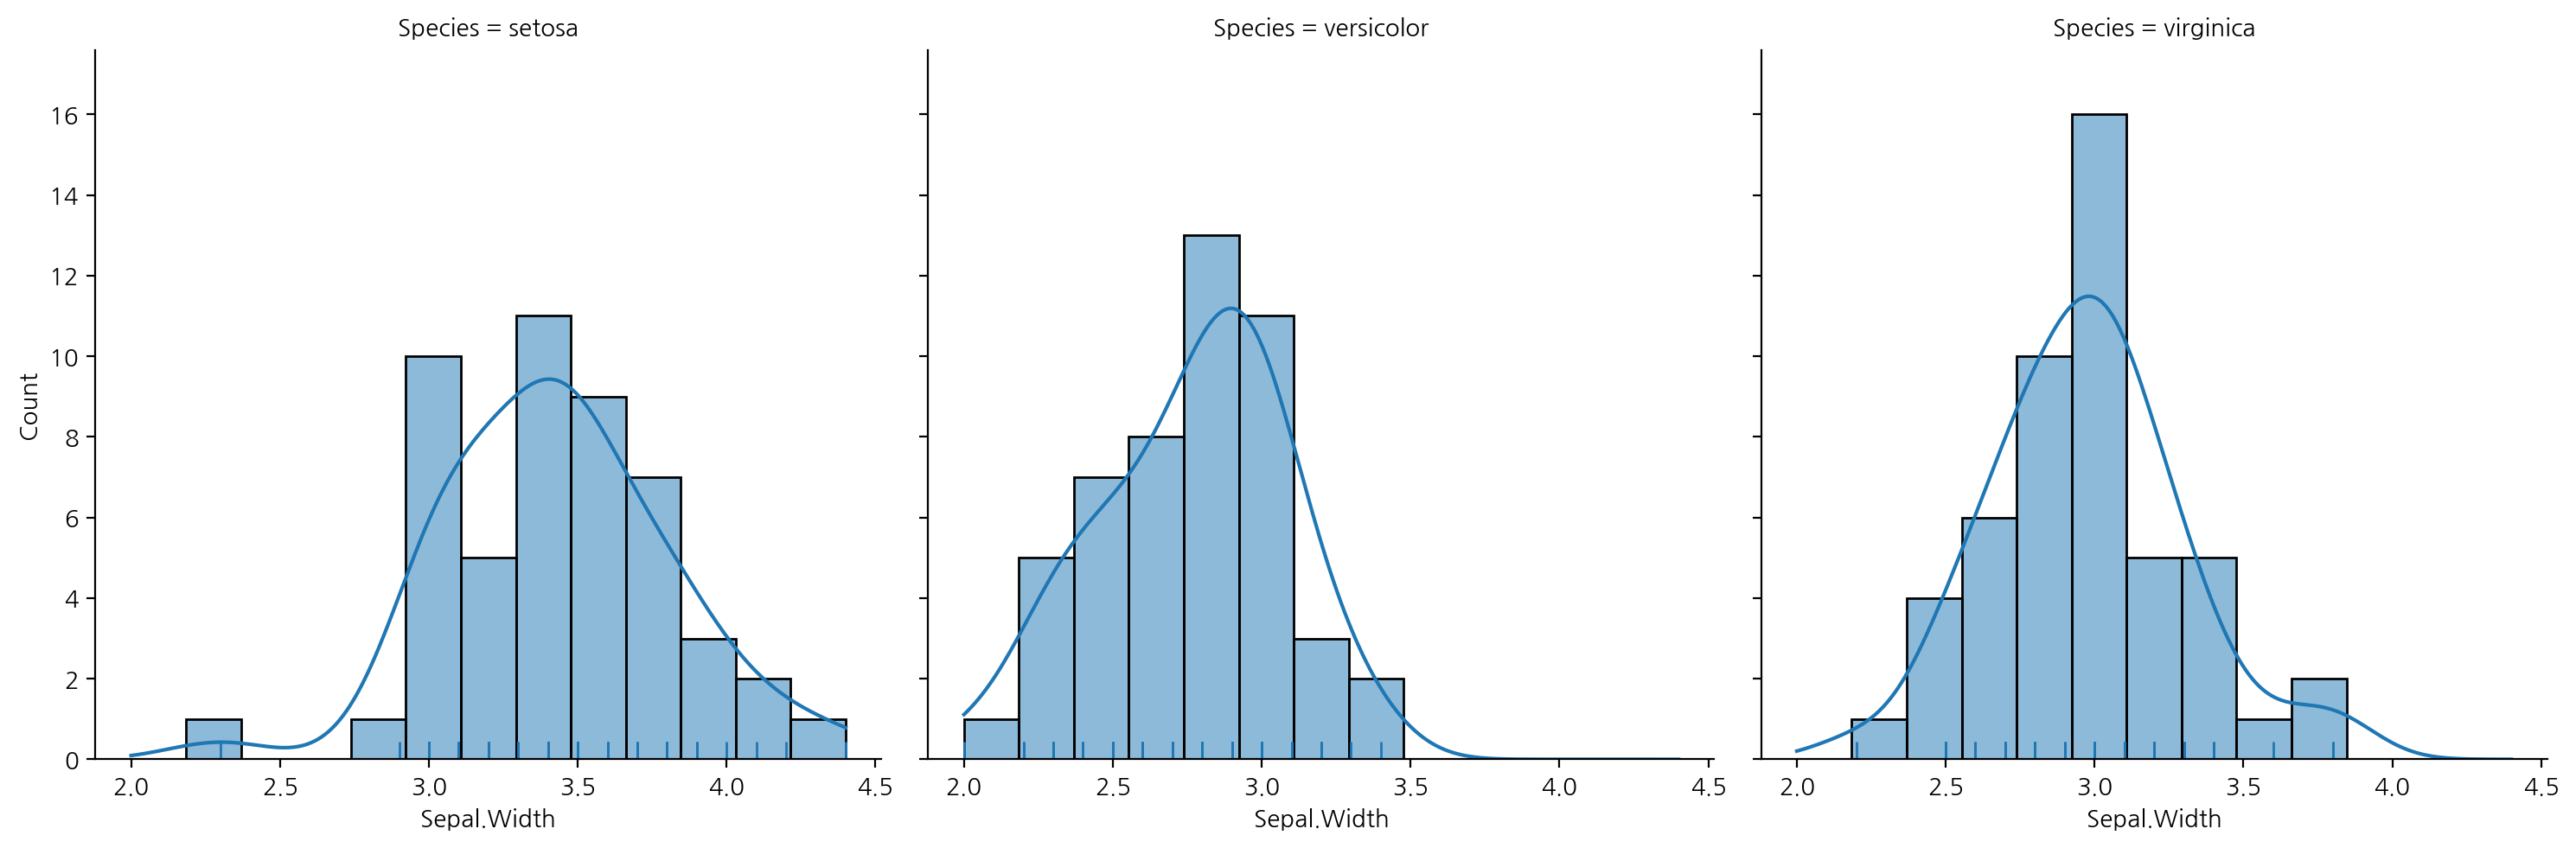

In [34]:
import seaborn as sns
sns.displot(data = iris, x = iris['Sepal.Width'], col="Species", kde=True, rug=True);

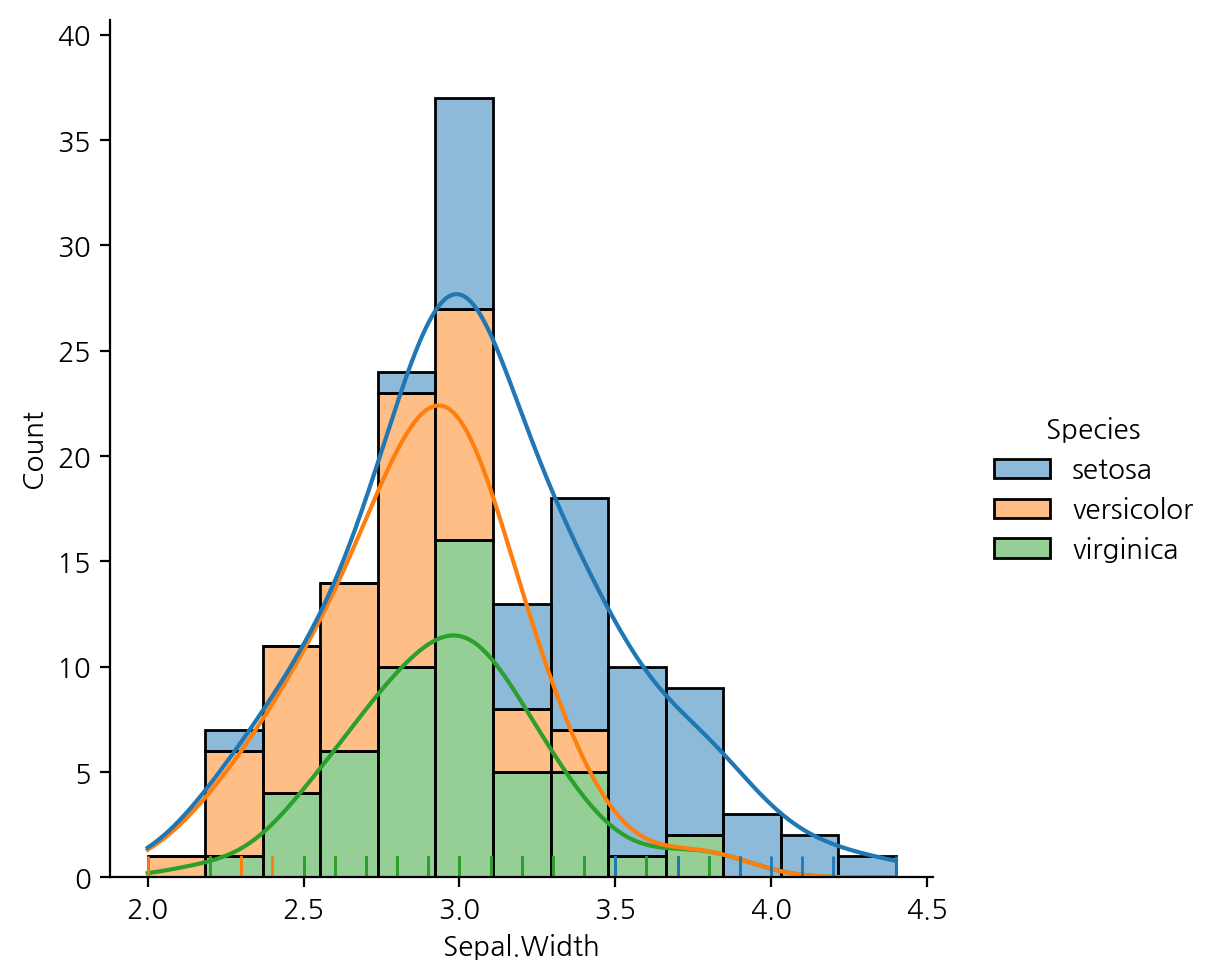

In [35]:
import seaborn as sns
sns.displot(data = iris, x = iris['Sepal.Width'], kde=True, rug=True, multiple="stack", hue="Species");

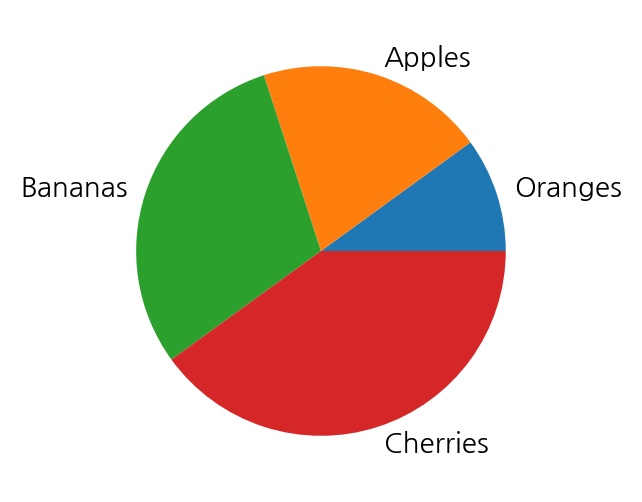

In [85]:
fruits = ["Oranges", "Apples", "Bananas", "Cherries"]
plt.pie([10, 20, 30, 40], labels = fruits); # 리스트 데이터를 바탕으로 파이 차트를 생성합니다.

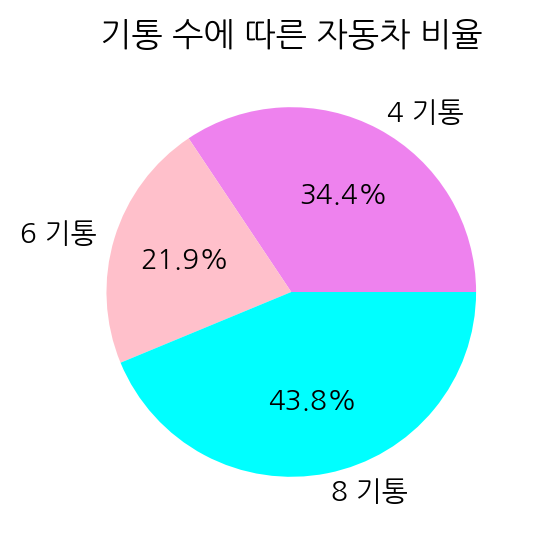

In [93]:
mtc = data('mtcars')
txt = [str(i) + ' 기통' for i in mtc.cyl.value_counts().sort_index().index]
plt.pie(mtc.cyl.value_counts().sort_index(),
        colors = ["violet", "pink", "aqua"],
        autopct = '%.1f%%', labels = txt)
plt.title("기통 수에 따른 자동차 비율");

In [95]:
mtc.gear.value_counts().sort_index()

,count
gear,
3,15
4,12
5,5


In [96]:
labels = [str(i) + ' 기어' for i in mtc.gear.value_counts().sort_index().index]
labels

['3 기어', '4 기어', '5 기어']

In [98]:
colors = sns.color_palette("Accent", len(labels))
colors

[(0.4980392156862745, 0.788235294117647, 0.4980392156862745),
 (0.7450980392156863, 0.6823529411764706, 0.8313725490196079),
 (0.9921568627450981, 0.7529411764705882, 0.5254901960784314)]

In [99]:
import seaborn as sns
colors = sns.color_palette('Set1', len(labels))
colors

[(0.8941176470588236, 0.10196078431372549, 0.10980392156862745),
 (0.21568627450980393, 0.49411764705882355, 0.7215686274509804),
 (0.30196078431372547, 0.6862745098039216, 0.2901960784313726)]

In [100]:
colors = sns.color_palette('Set2', 7)
colors

[(0.4, 0.7607843137254902, 0.6470588235294118),
 (0.9882352941176471, 0.5529411764705883, 0.3843137254901961),
 (0.5529411764705883, 0.6274509803921569, 0.796078431372549),
 (0.9058823529411765, 0.5411764705882353, 0.7647058823529411),
 (0.6509803921568628, 0.8470588235294118, 0.32941176470588235),
 (1.0, 0.8509803921568627, 0.1843137254901961),
 (0.8980392156862745, 0.7686274509803922, 0.5803921568627451)]

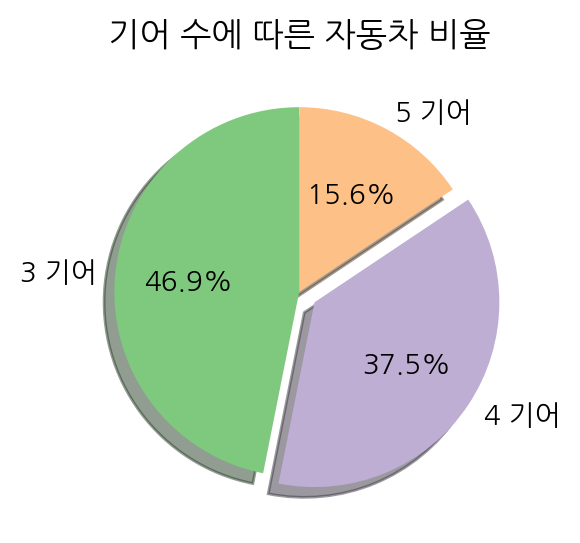

In [102]:
colors = sns.color_palette('Accent', len(txt))
plt.pie(mtc.gear.value_counts().sort_index(), colors = colors, explode = [0, .1, 0],
        shadow = True, startangle=90, autopct = '%.1f%%', labels = labels)
plt.title("기어 수에 따른 자동차 비율");

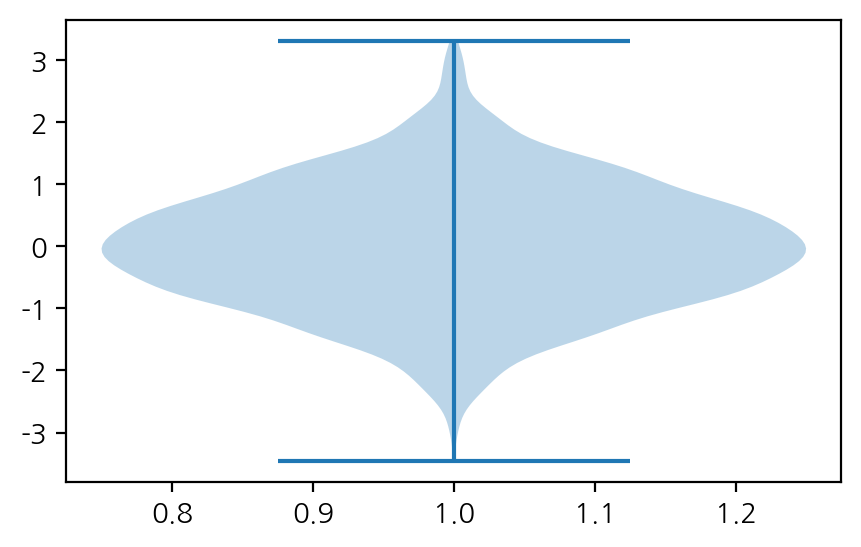

In [103]:
data = np.random.randn(2000)
plt.violinplot(data);

{'bodies': [<matplotlib.collections.FillBetweenPolyCollection at 0x7ac60317bc50>],
 'cmaxes': <matplotlib.collections.LineCollection at 0x7ac5f13b9dc0>,
 'cmins': <matplotlib.collections.LineCollection at 0x7ac5f13ba7b0>,
 'cbars': <matplotlib.collections.LineCollection at 0x7ac5f13bab40>,
 'cquantiles': <matplotlib.collections.LineCollection at 0x7ac5f1315430>}

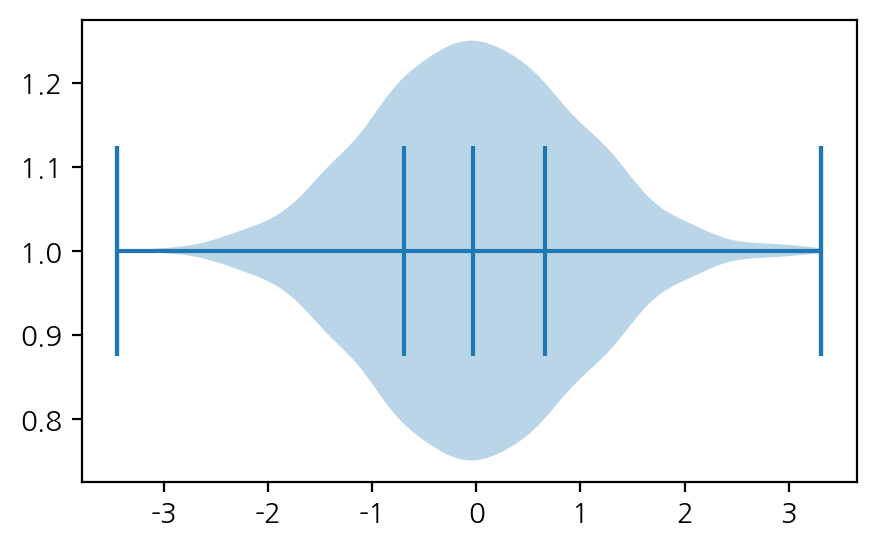

In [105]:
plt.violinplot(data, quantiles=[0, .25, .5, .75, 1], vert = False)

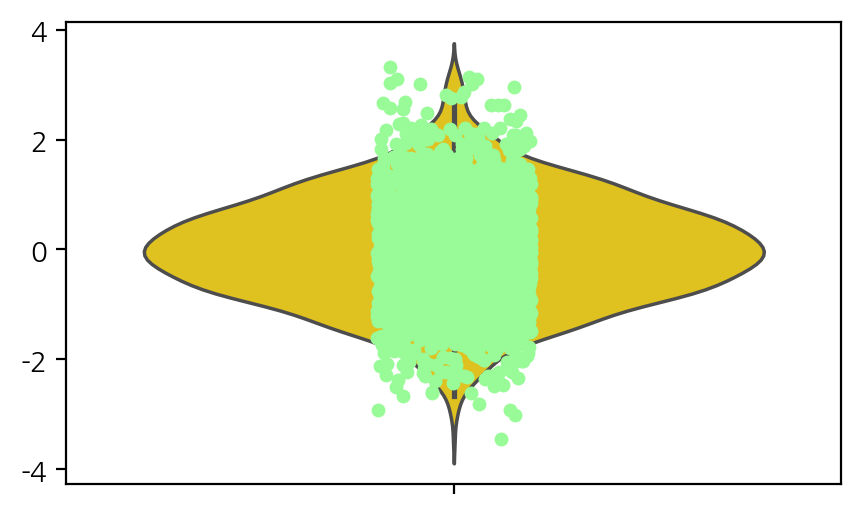

In [106]:
import seaborn as sns
sns.violinplot(data, color='gold');
sns.stripplot(data, color='palegreen');

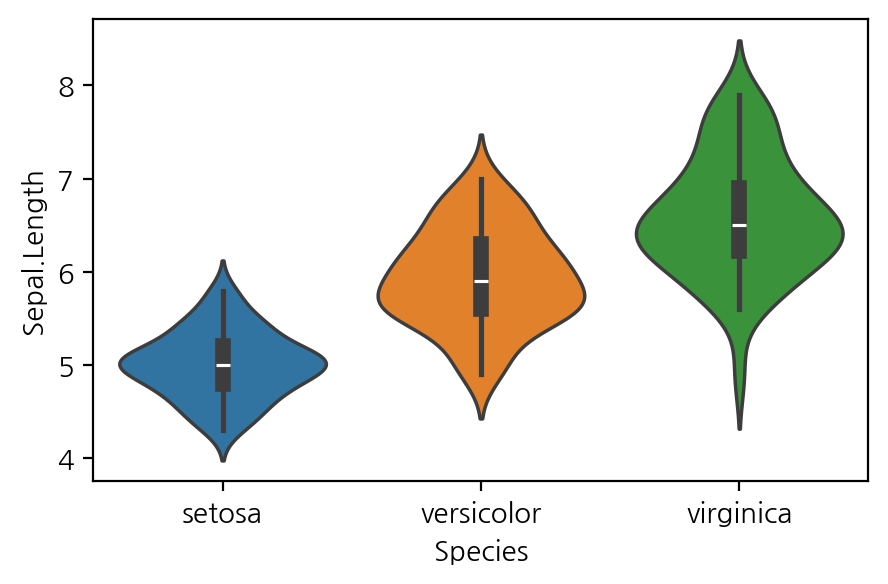

In [112]:
from pydataset import data
iris = data('iris')

import seaborn as sns
sns.violinplot(iris, x = 'Species', y ='Sepal.Length', hue = 'Species');

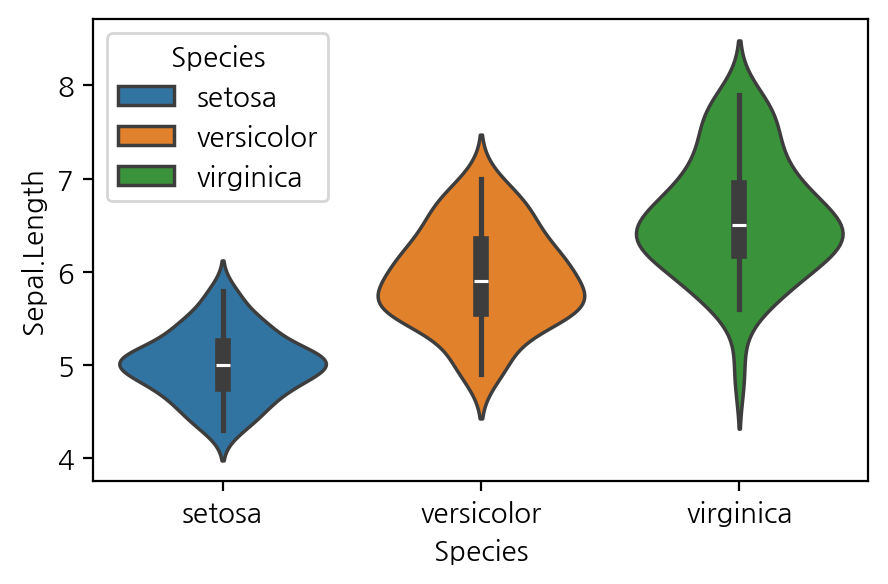

In [113]:
sns.violinplot(iris, x = 'Species', y ='Sepal.Length', hue = 'Species', legend = 'full');

In [114]:
from pydataset import data
mtc = data('mtcars')
mtc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32 entries, Mazda RX4 to Volvo 142E
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   mpg     32 non-null     float64
 1   cyl     32 non-null     int64  
 2   disp    32 non-null     float64
 3   hp      32 non-null     int64  
 4   drat    32 non-null     float64
 5   wt      32 non-null     float64
 6   qsec    32 non-null     float64
 7   vs      32 non-null     int64  
 8   am      32 non-null     int64  
 9   gear    32 non-null     int64  
 10  carb    32 non-null     int64  
dtypes: float64(5), int64(6)
memory usage: 3.0+ KB


In [117]:
mincars = mtc.iloc[:, :4] # 모든 행과 4번째 열까지
mincars.head() # 5번째 행까지만 출력

,mpg,cyl,disp,hp
Mazda RX4,21.0,6,160.0,110
Mazda RX4 Wag,21.0,6,160.0,110
Datsun 710,22.8,4,108.0,93
Hornet 4 Drive,21.4,6,258.0,110
Hornet Sportabout,18.7,8,360.0,175


In [118]:
print(mtc.columns[:4])
print(mtc.columns[:4].to_list())

Index(['mpg', 'cyl', 'disp', 'hp'], dtype='object')
['mpg', 'cyl', 'disp', 'hp']


In [122]:
mincars = mtc[mtc.columns[:4].to_list()]
mincars.head(3)

,mpg,cyl,disp,hp
Mazda RX4,21.0,6,160.0,110
Mazda RX4 Wag,21.0,6,160.0,110
Datsun 710,22.8,4,108.0,93


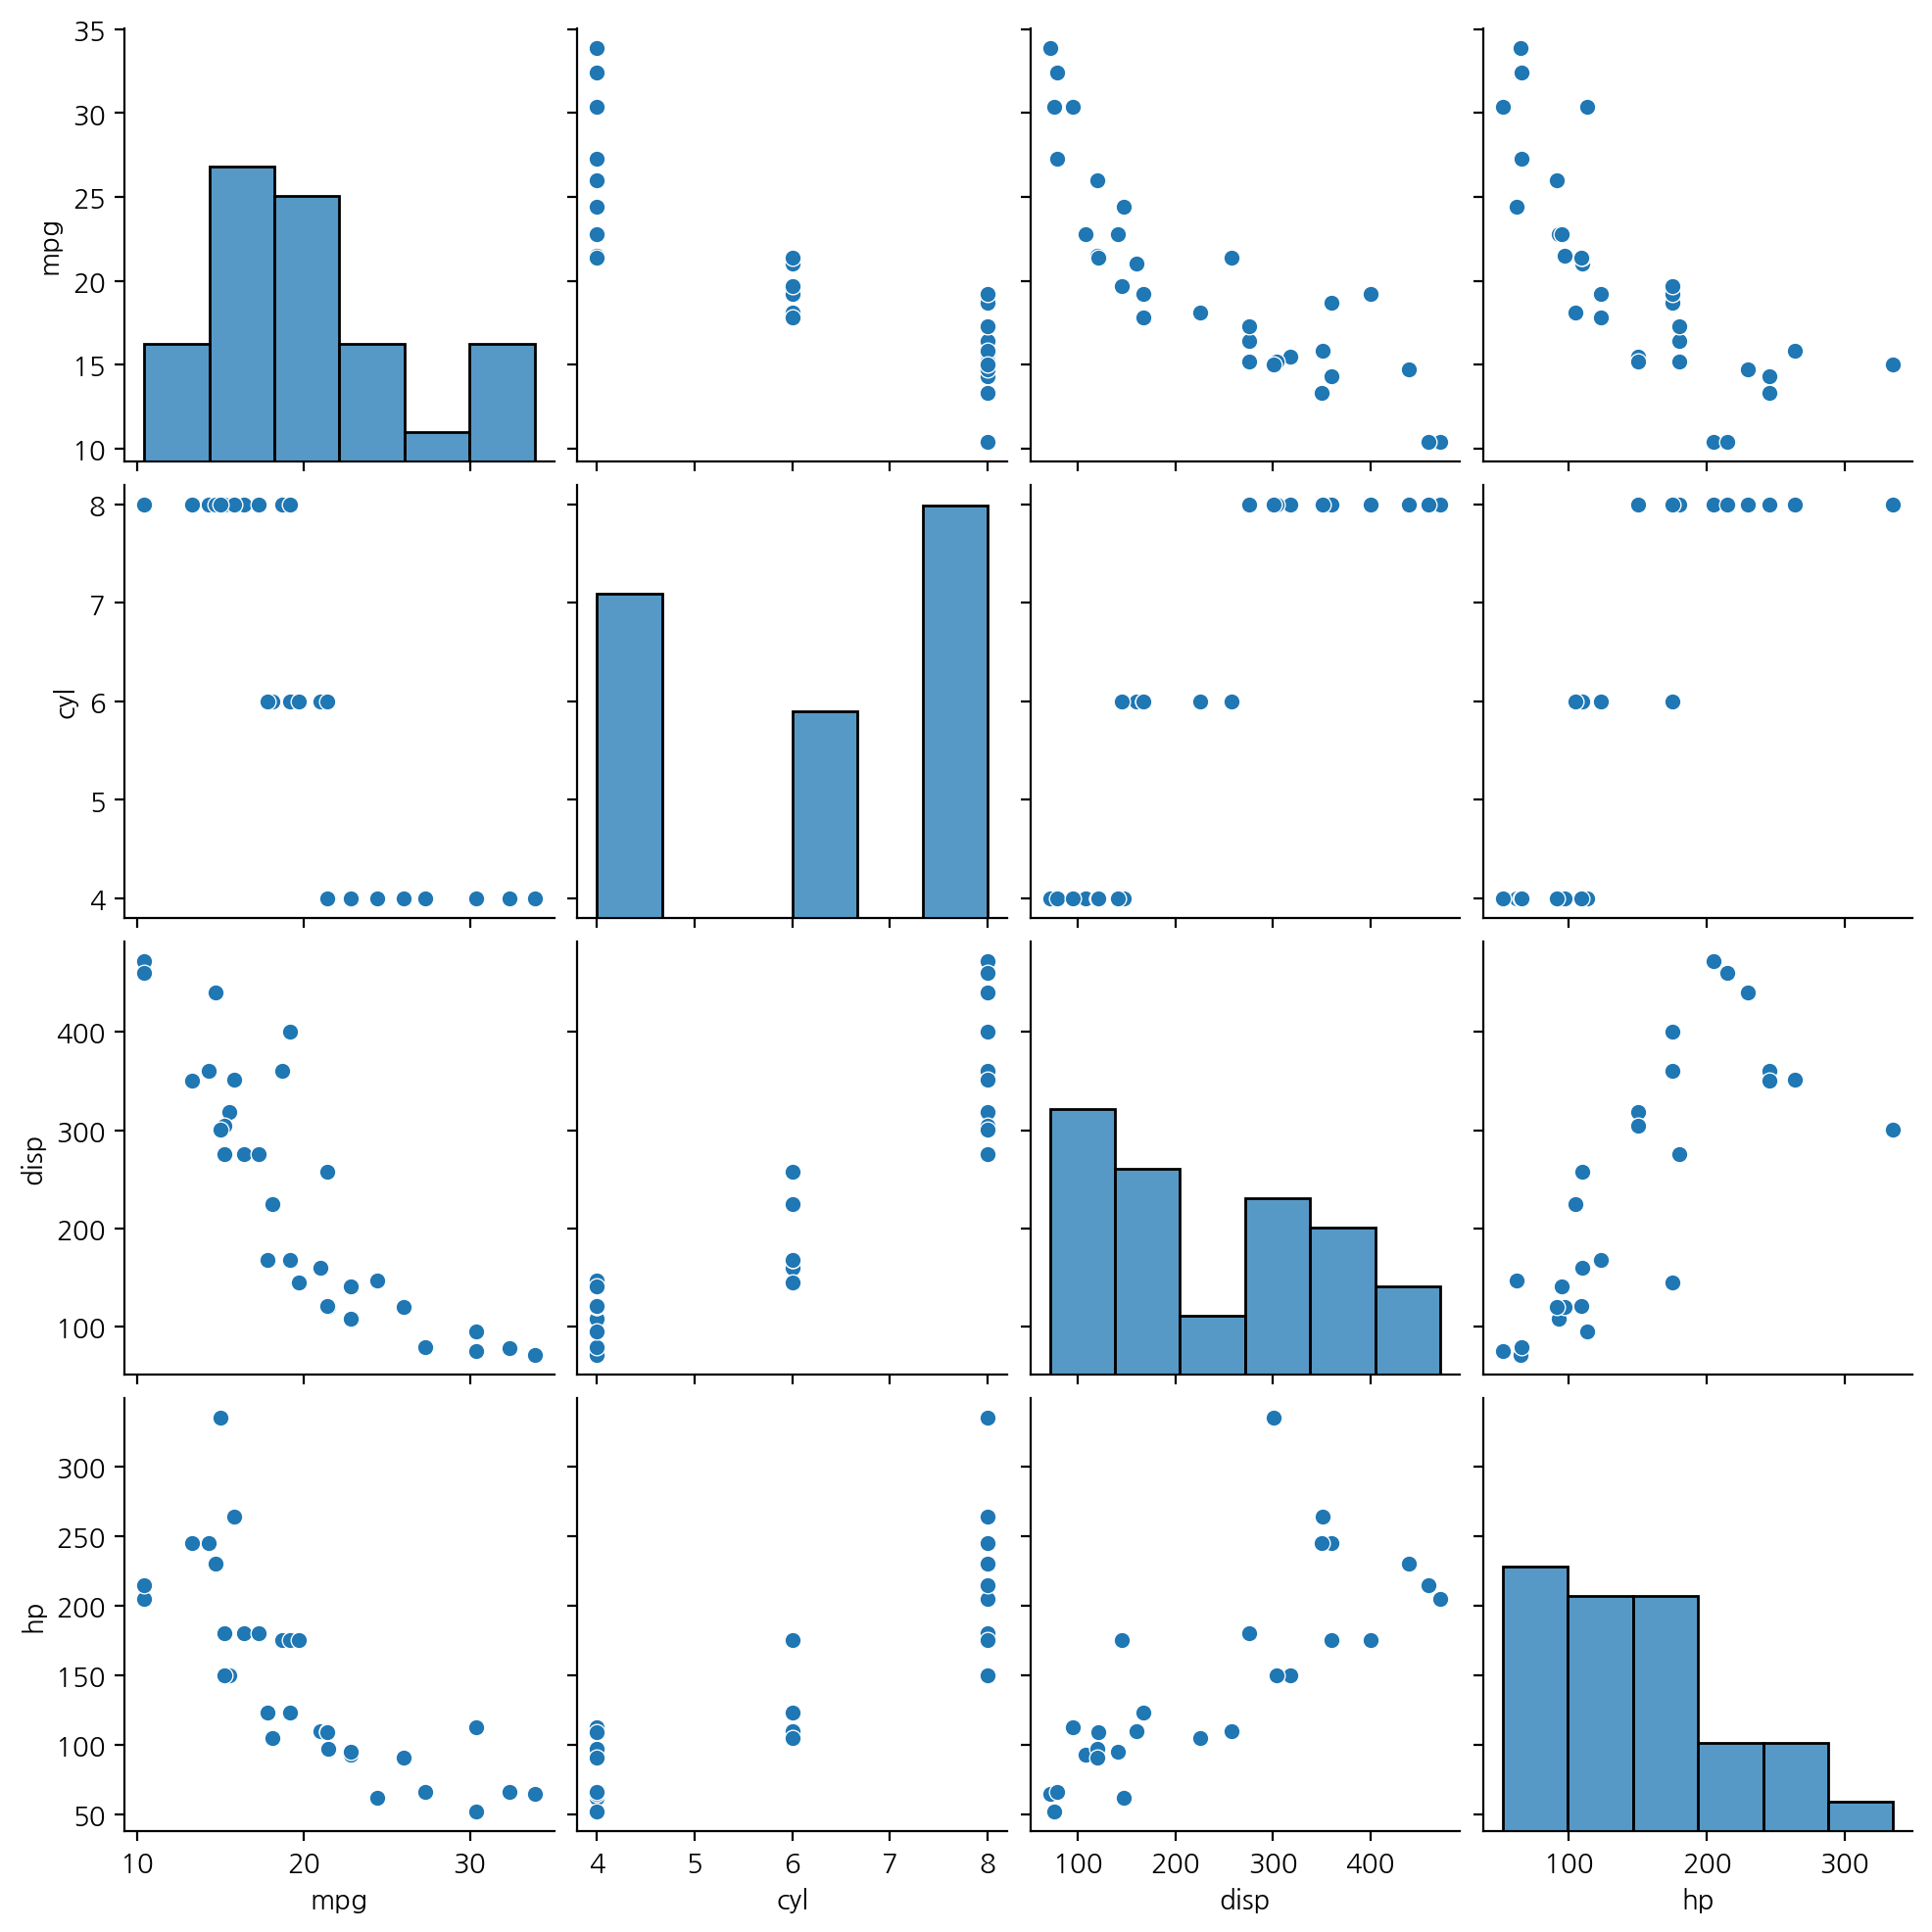

In [123]:
sns.pairplot(mincars);

In [36]:
import seaborn as sns
iris = sns.load_dataset("iris")
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [86]:
pd.set_option('display.precision', 2) # 데이터프레임 출력 시 소수점 둘째 자리까지 표시하도록 설정합니다.

In [38]:
iris.columns[:-1].tolist()

['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

In [72]:
corr = iris[iris.columns[:-1].tolist()].corr() # 수치형 컬럼들 간의 상관계수 행렬을 계산합니다.
corr

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
Sepal.Length,1.00,-0.12,0.87,0.82
Sepal.Width,-0.12,1.00,-0.43,-0.37
Petal.Length,0.87,-0.43,1.00,0.96
Petal.Width,0.82,-0.37,0.96,1.00


<Axes: >

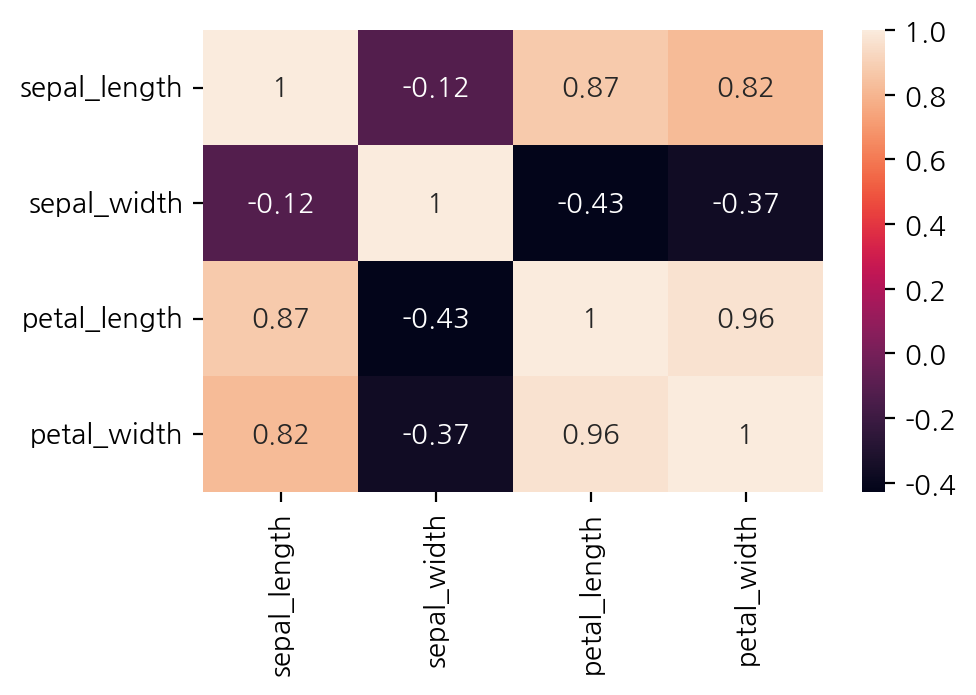

In [40]:
sns.heatmap(corr, annot = True)

<Axes: >

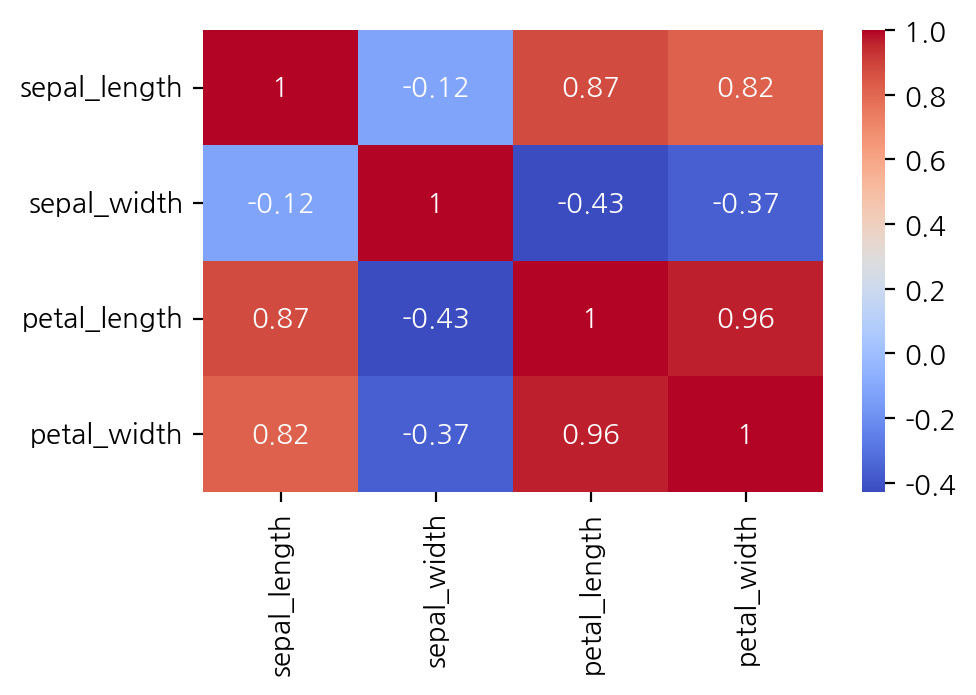

In [41]:
sns.heatmap(corr, cmap = 'coolwarm', annot = True)

<Axes: >

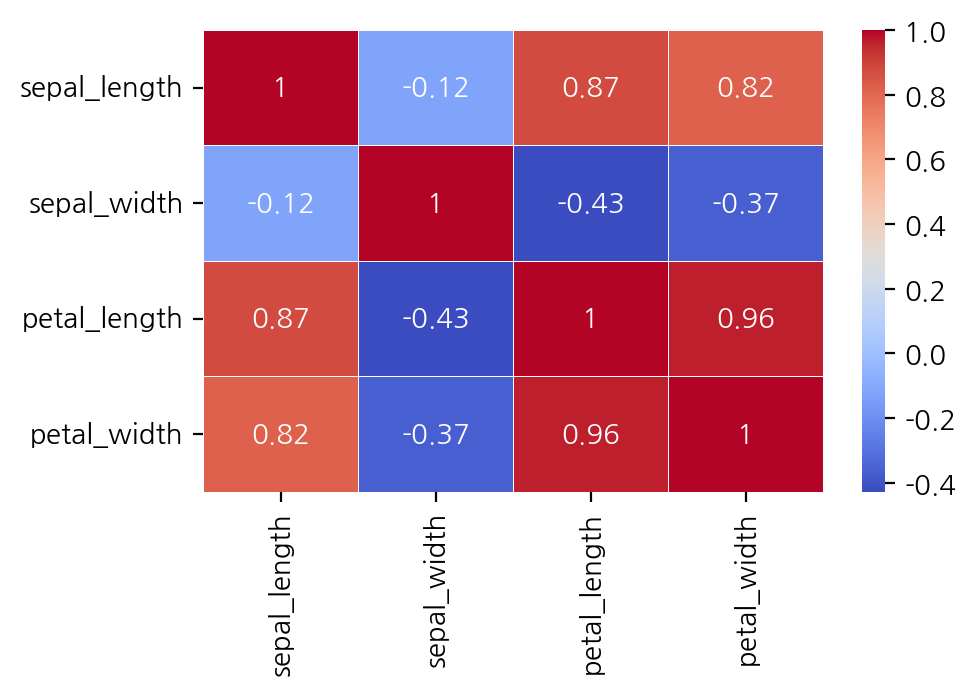

In [42]:
sns.heatmap(corr, cmap = 'coolwarm', annot = True, lw=.2)

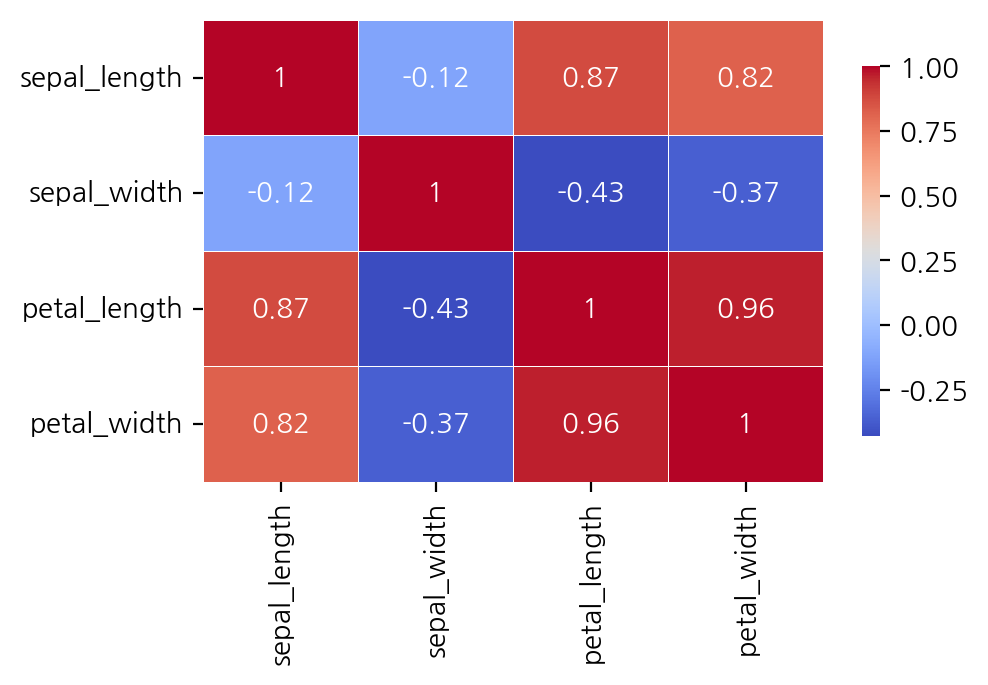

In [43]:
sns.heatmap(corr, cmap = 'coolwarm', annot = True, lw = .2, cbar_kws = {'shrink' : .8} );

In [44]:
mask = np.zeros_like(corr)
mask

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

In [45]:
np.triu_indices_from(mask)

(array([0, 0, 0, 0, 1, 1, 1, 2, 2, 3]), array([0, 1, 2, 3, 1, 2, 3, 2, 3, 3]))

In [46]:
mask[np.triu_indices_from(mask)] = True
mask

array([[1., 1., 1., 1.],
       [0., 1., 1., 1.],
       [0., 0., 1., 1.],
       [0., 0., 0., 1.]])

In [48]:
mask_new = mask[1:, :-1]
mask_new

array([[0., 1., 1.],
       [0., 0., 1.],
       [0., 0., 0.]])

In [49]:
corr

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.00,-0.12,0.87,0.82
sepal_width,-0.12,1.00,-0.43,-0.37
petal_length,0.87,-0.43,1.00,0.96
petal_width,0.82,-0.37,0.96,1.00


In [50]:
corr_iris_new = corr.iloc[1:, :-1] # 첫 번째 행 제거, 마지막 열 제거
corr_iris_new

,sepal_length,sepal_width,petal_length
sepal_width,-0.12,1.00,-0.43
petal_length,0.87,-0.43,1.00
petal_width,0.82,-0.37,0.96


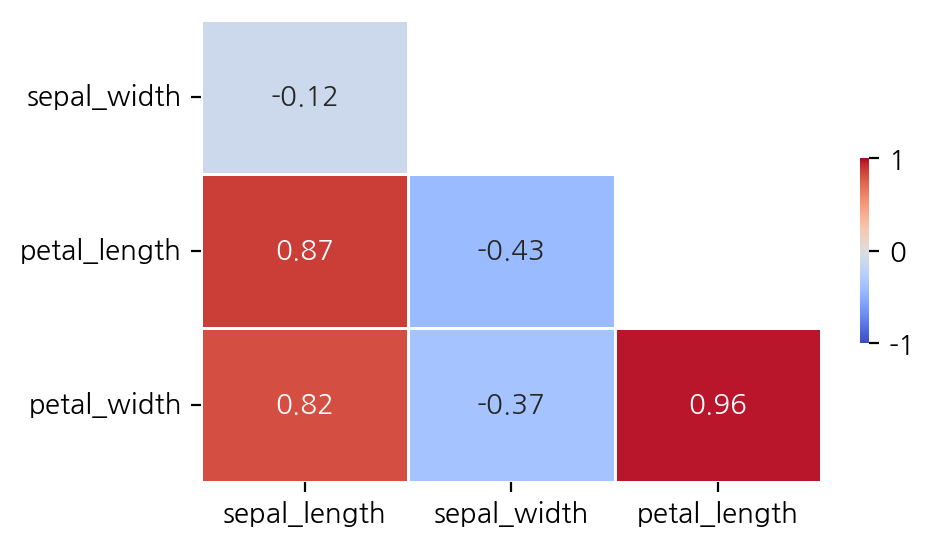

In [63]:
# 상관계수 행렬의 하단 삼각형만 히트맵으로 시각화
sns.heatmap(corr_iris_new, annot = True, cmap = 'coolwarm', mask = mask_new,
            annot_kws = {"size" : 10}, vmin = -1, vmax =1,
            cbar_kws = {'shrink' : .4},
            linewidths =.5);

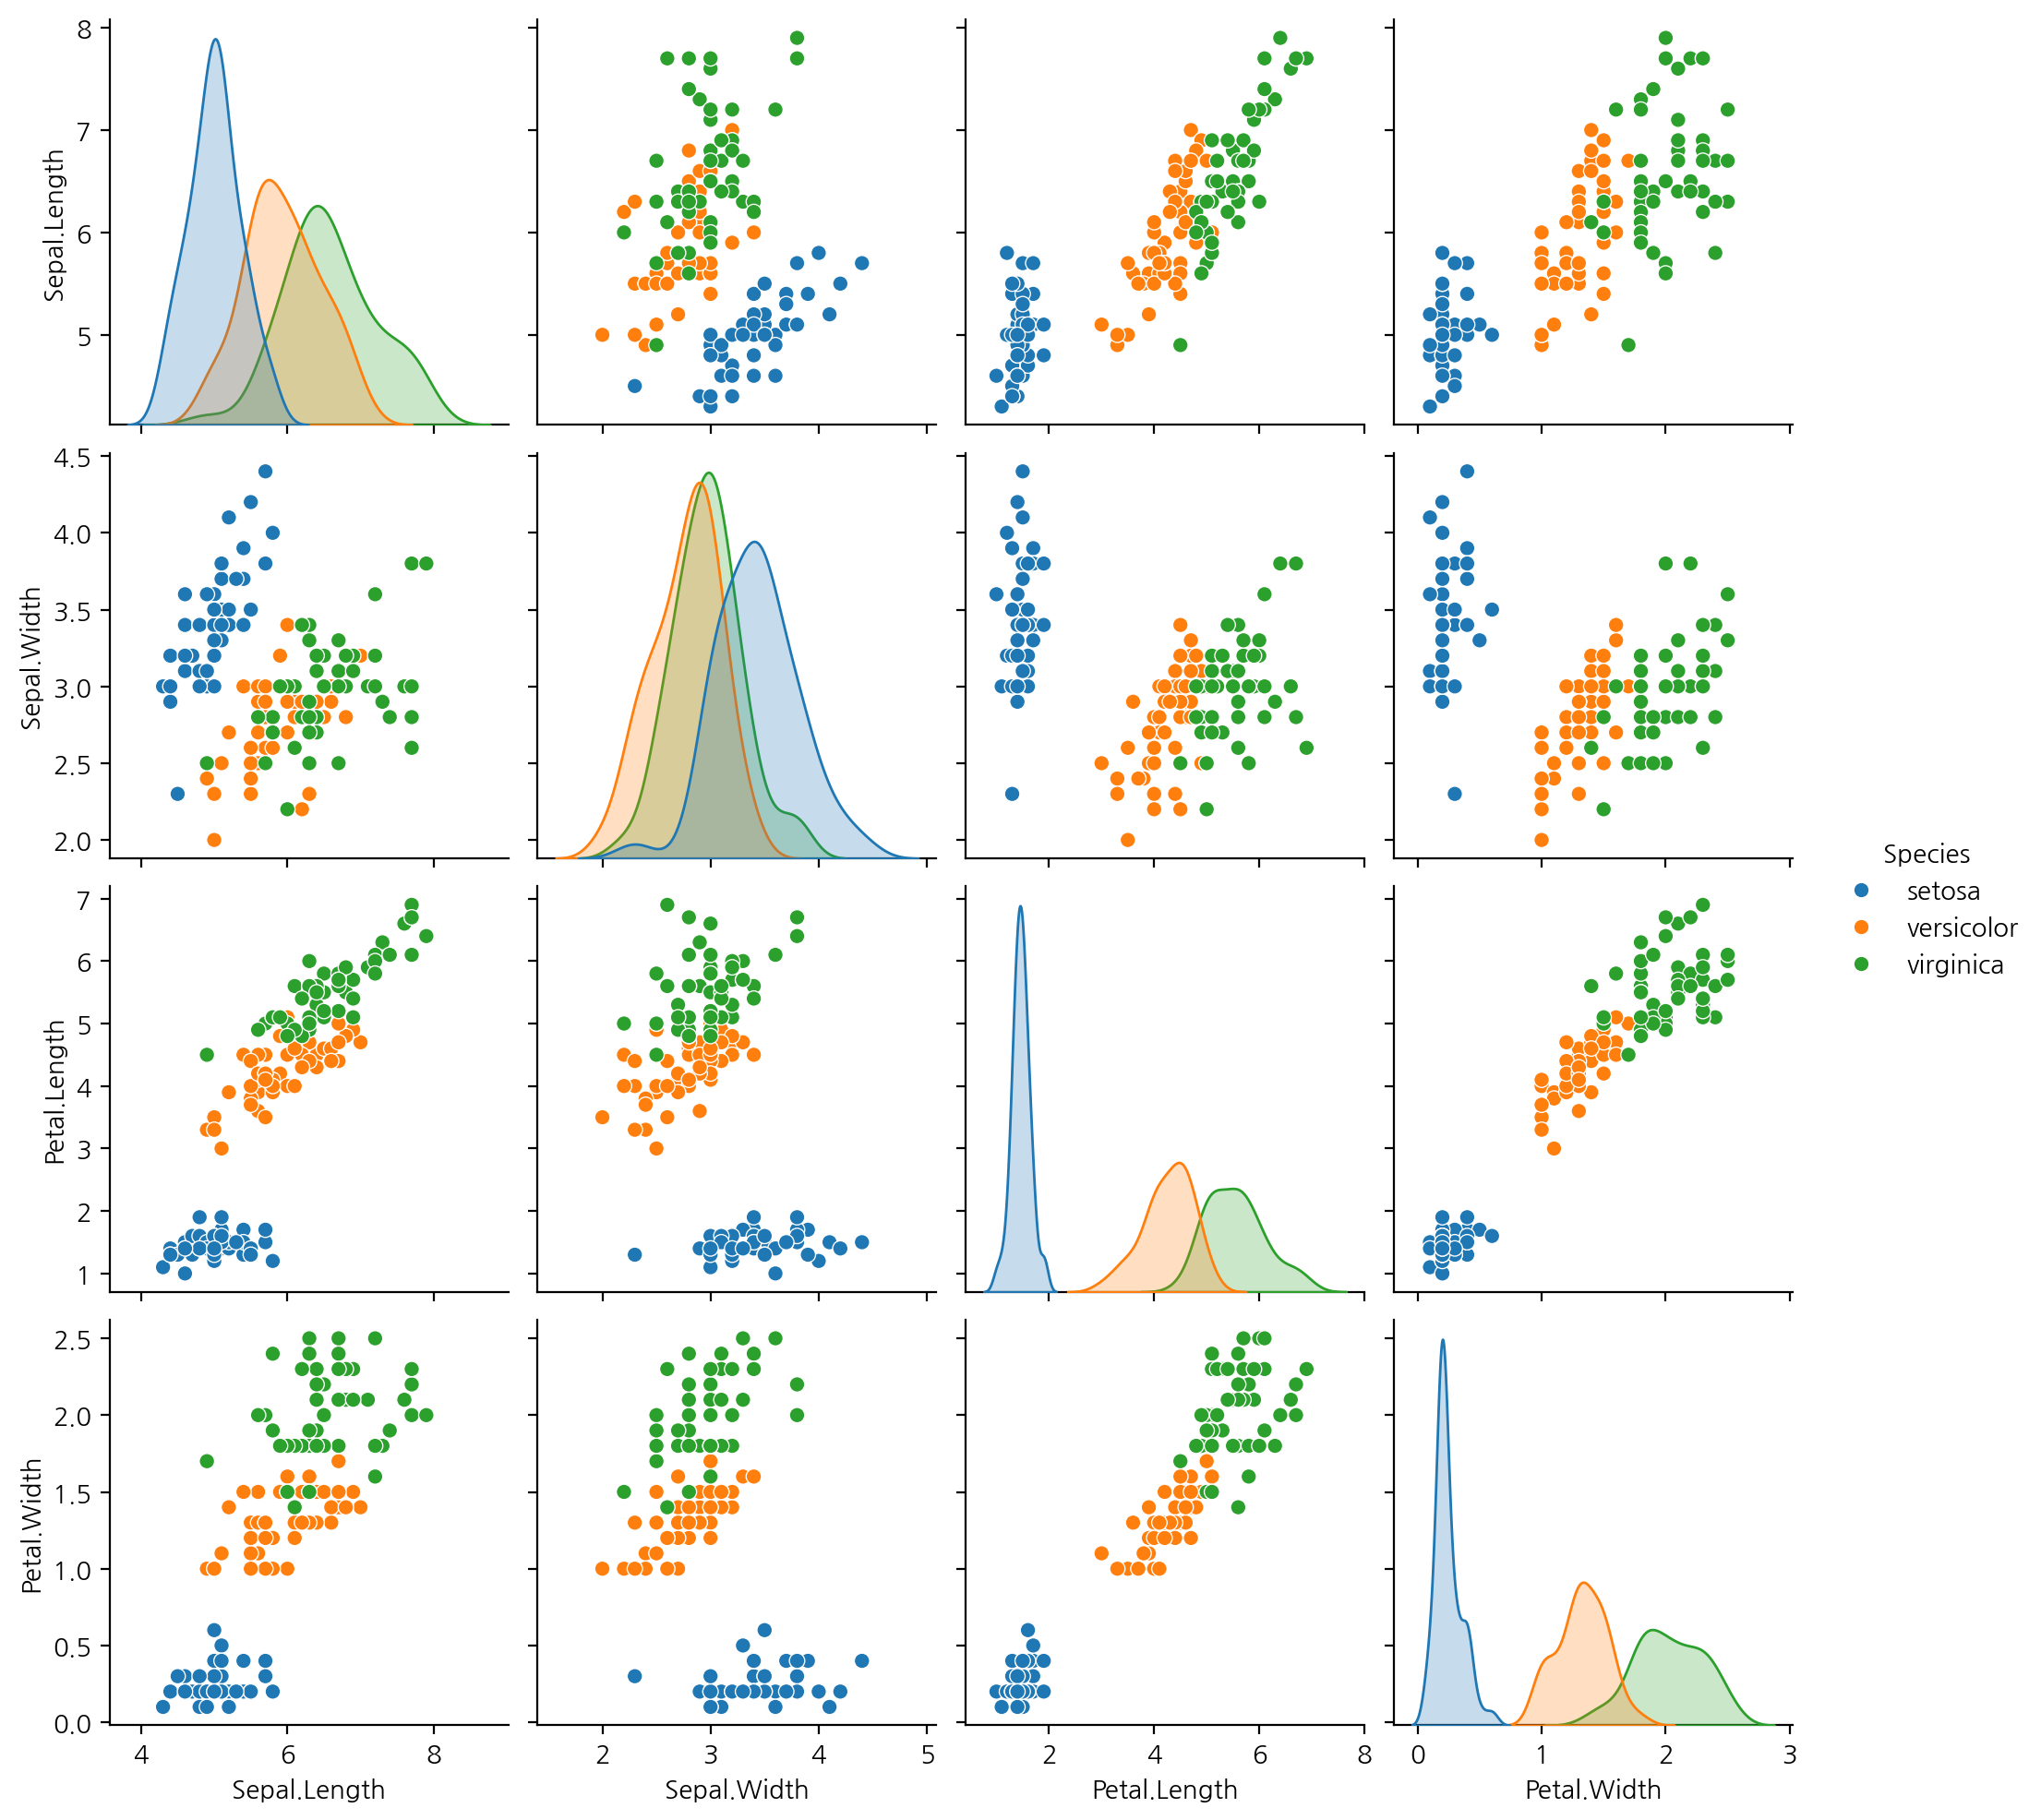

In [76]:
sns.pairplot(iris, hue = 'Species'); # 모든 변수 쌍에 대한 산점도 행렬을 그리며, 종(Species)별로 색상을 구분합니다.

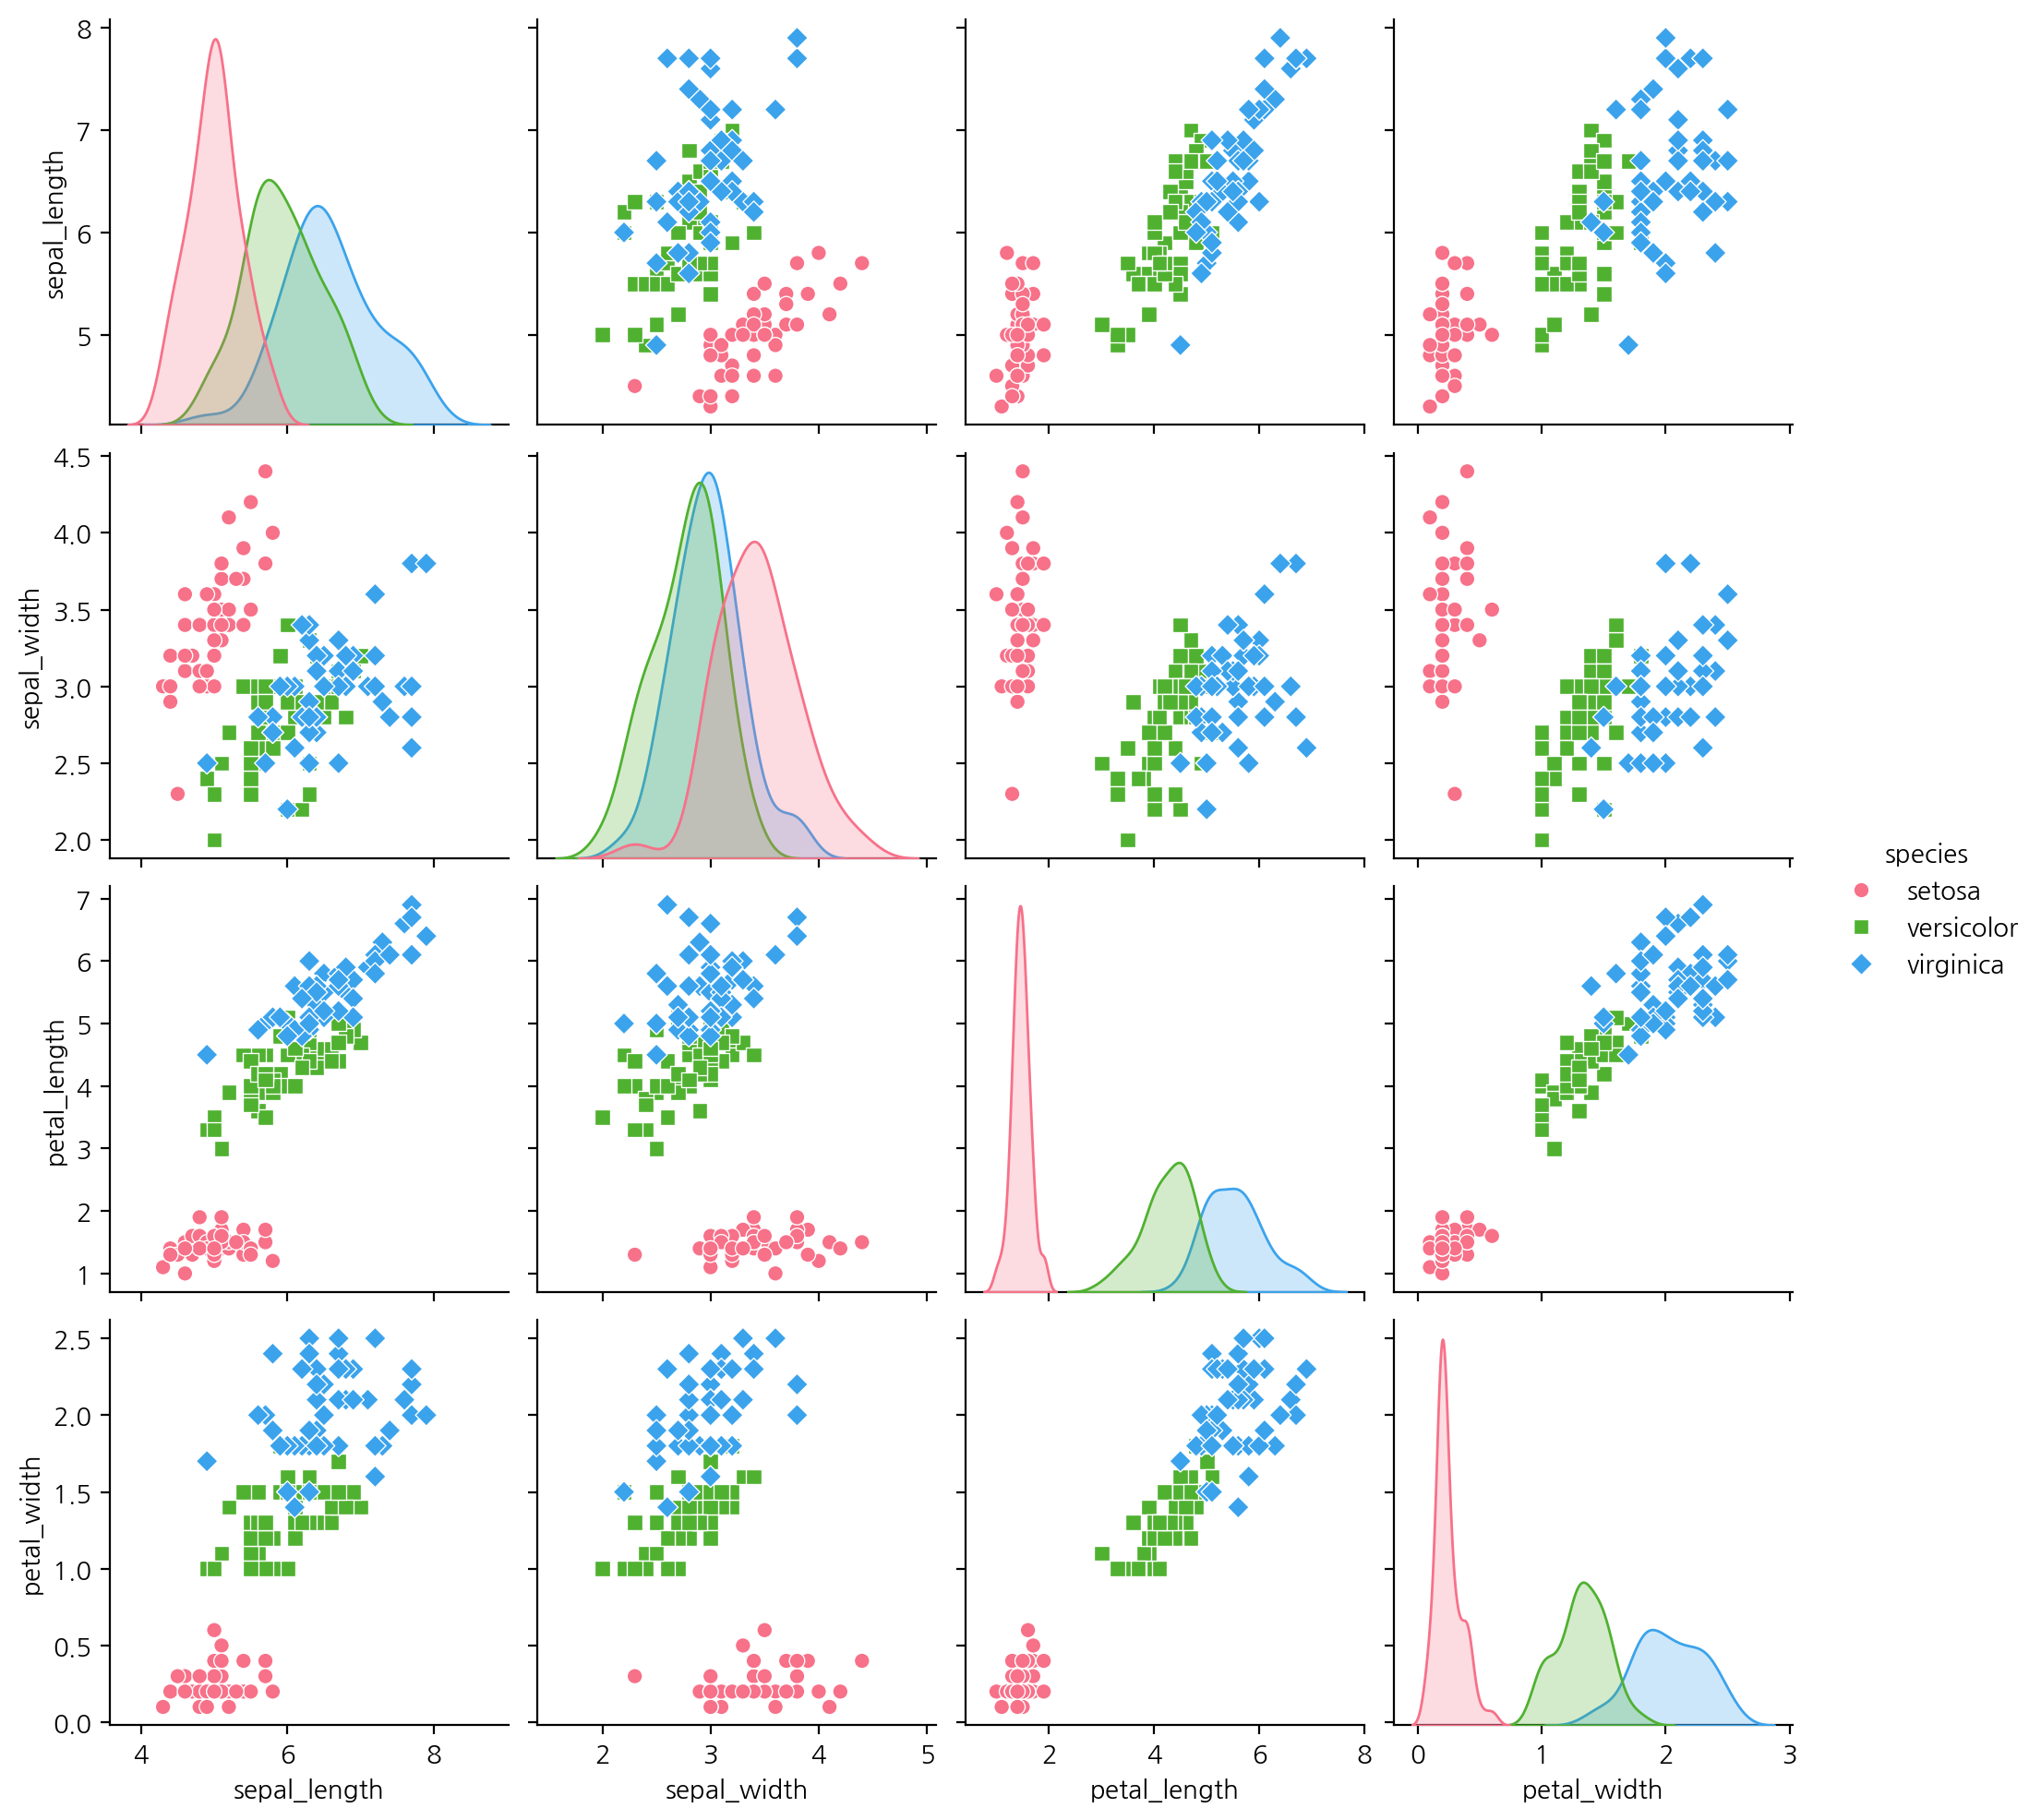

In [56]:
sns.pairplot(iris, hue="species", palette="husl", markers=["o", "s", "D"]);

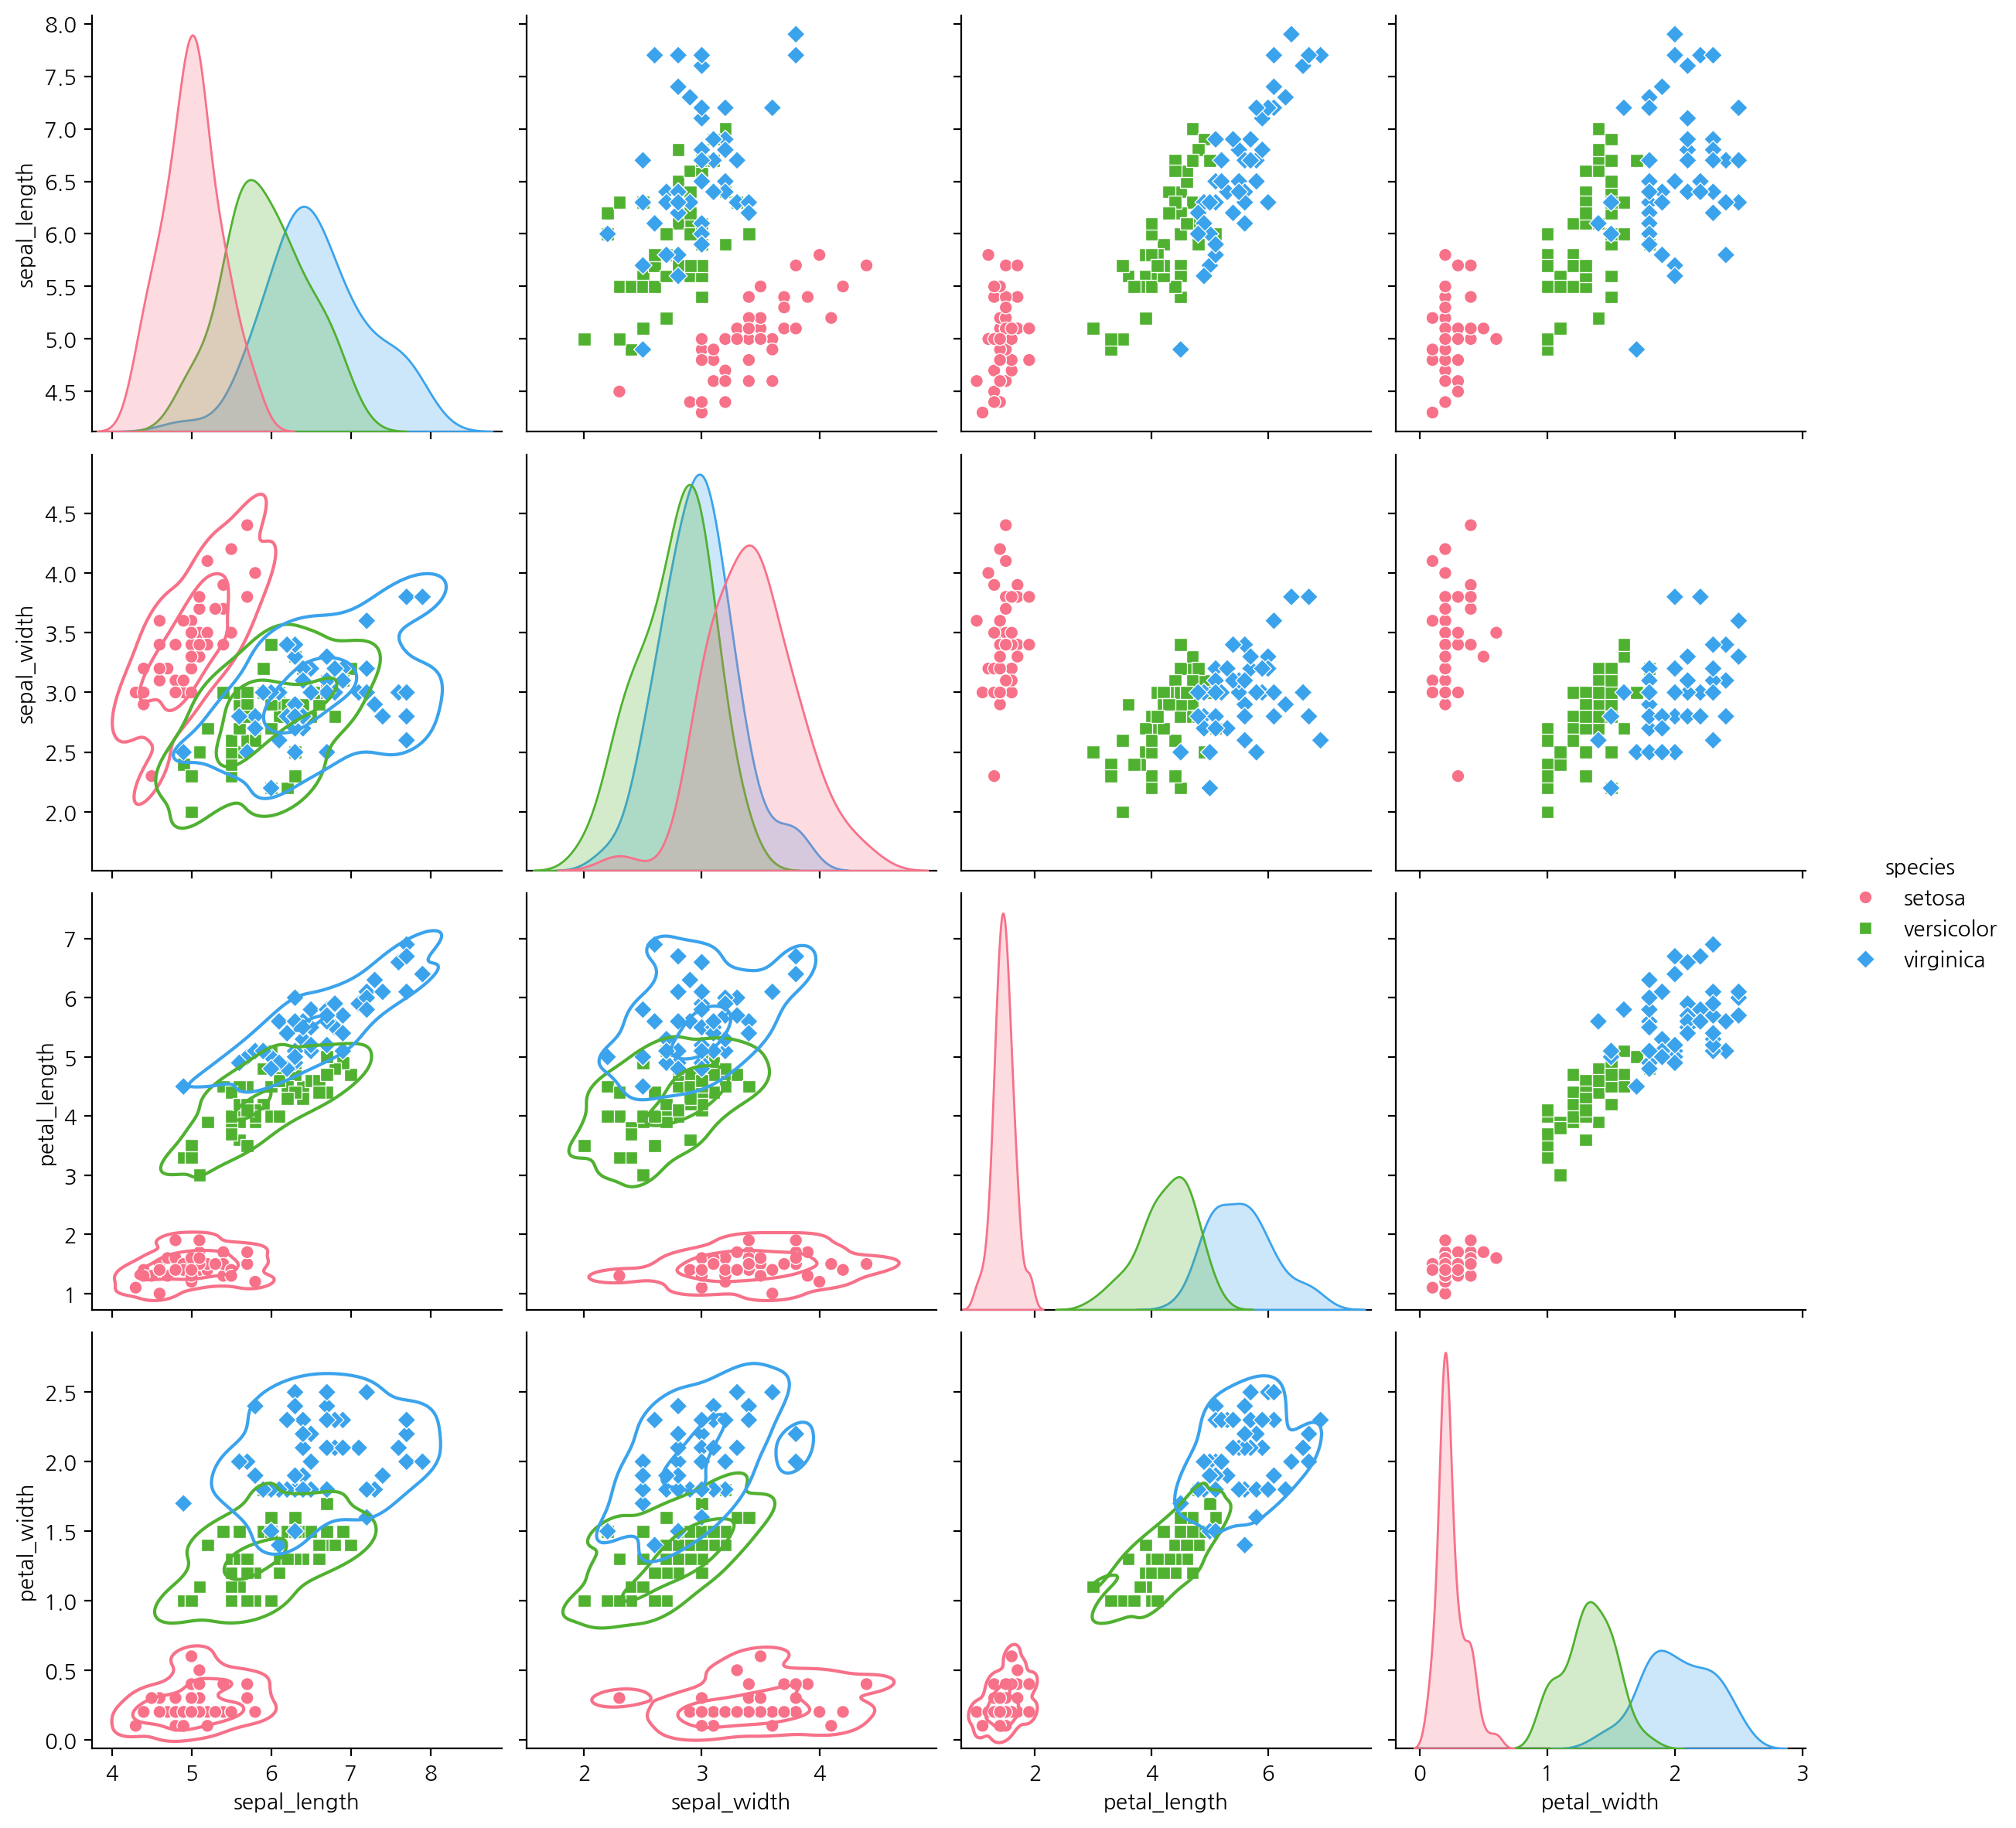

In [57]:
g = sns.pairplot(iris, hue="species", palette="husl", height=3, markers=["o", "s", "D"]);
g.map_lower(sns.kdeplot, levels=3); # 동고선의 색상, 0==검정, 1==흰색, hue 색상으로 구분 여려움

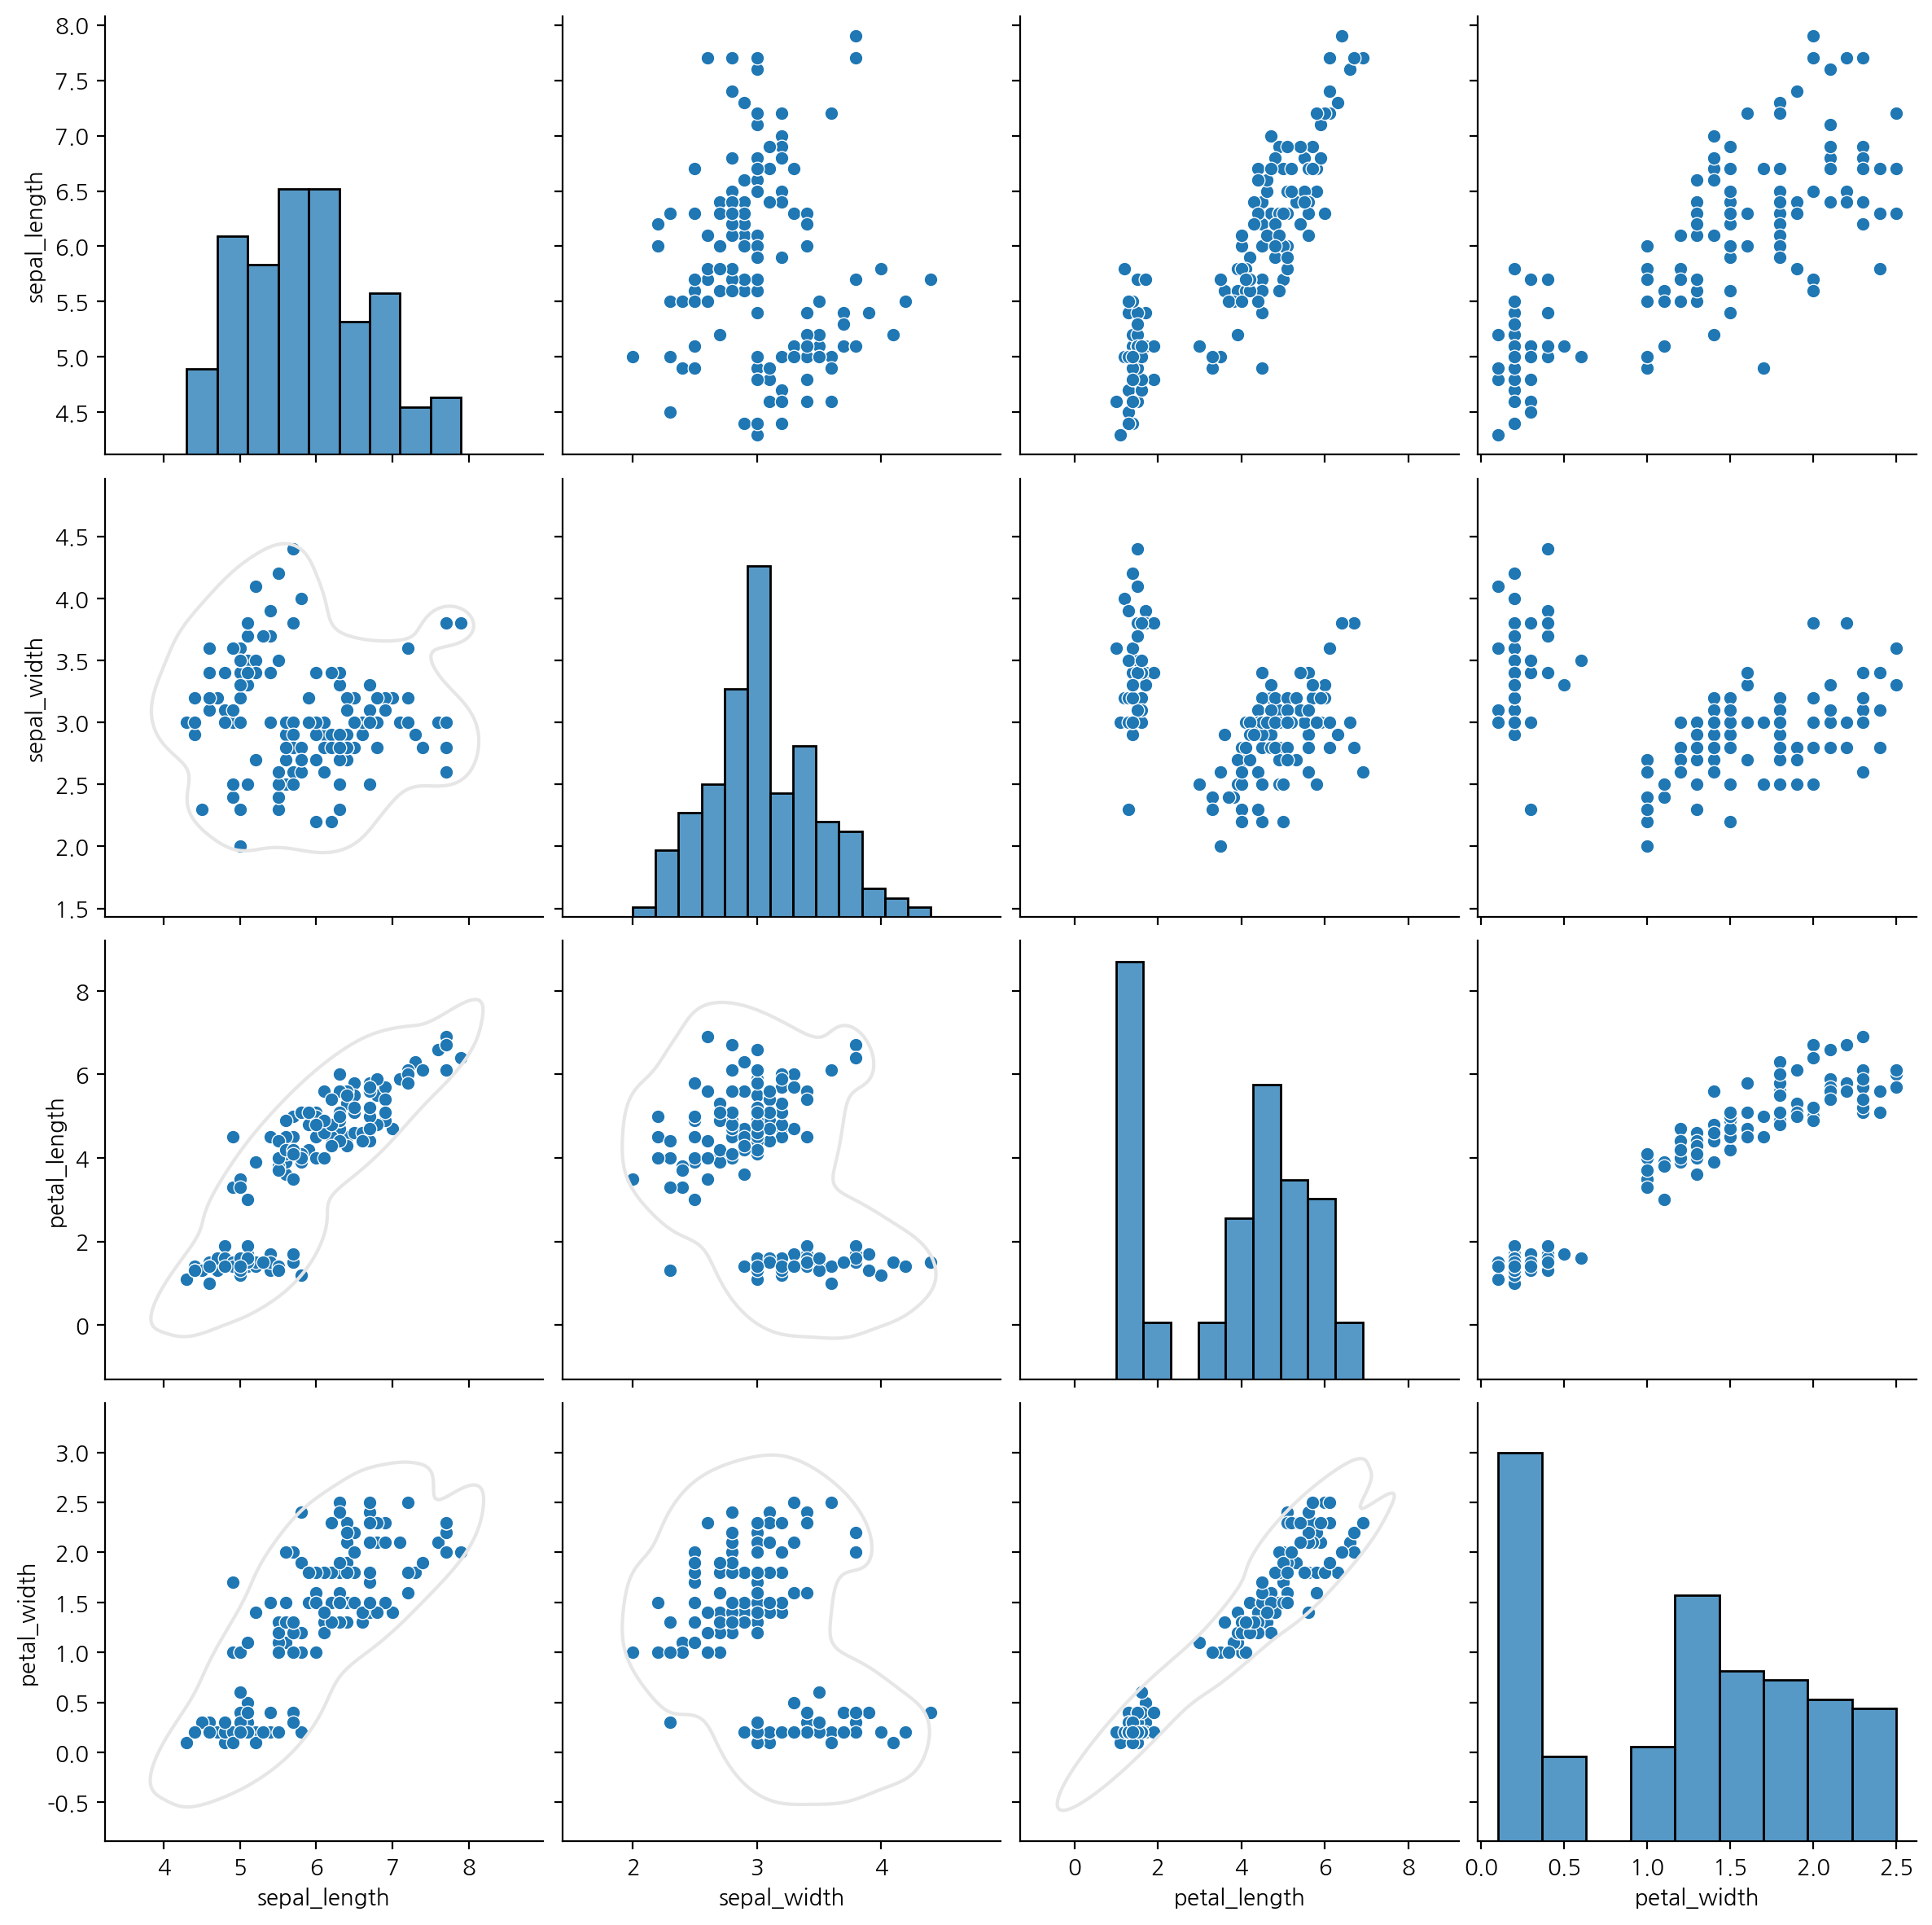

In [59]:
g = sns.pairplot(iris, height=3); # pairplot 객체 생성, 각 서브플롯의 높이를 3으로 설정
g.map_lower(sns.kdeplot, levels=2, color=".9"); # 하단 삼각형 영역에 2단계 등고선을 가진 KDE 플롯 추가, 색상은 회색 계열